In [1]:
import numpy as np
import xarray as xr
import json

import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.optimize import curve_fit

from feature_retreiver import *

In [2]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(latitude * np.pi / 180)

In [3]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [4]:
def calculate_mean_over_inertial_period(
        data: np.ndarray,
        latitudes: np.ndarray,
        dt: float = 50
) -> np.ndarray:
    m, _ = data.shape
    ten_days = 10 * 24 * 60 * 60  # HARD CODED BABEY; this is the issue with the long runs; should be accounted for
    averages, variances = np.empty(m), np.empty(m)
    for i in range(m):
        if latitudes[i] <= 5:
            averages[i], variances[i] = np.nanmean(data[i]), np.nanstd(data[i])
        else:
            inertial_period = calculate_T(latitude=latitudes[i])
            n_steps_per_period = int(inertial_period / dt)
            array = data[i, n_steps_per_period:]  # discard the first inertial period
            n_chunks = int(ten_days / inertial_period) - 1
            average, variance = np.empty(n_chunks + 1), np.empty(n_chunks + 1)
            for j in range(n_chunks):
                start, end = n_steps_per_period*j, n_steps_per_period*(j+1)
                average[j], variance[j] = np.nanmean(array[start:end]), np.nanstd(array[start:end]) ** 2
            average[n_chunks], variance[n_chunks] = np.nanmean(array[end:]), np.nanstd(array[end:]) ** 2
            averages[i], variances[i] = np.nanmean(average), np.nanmean(variance)
    return averages, variances

In [5]:
def calculate_rolling_average(
        case: str,
        dataset: xr.DataArray,
        variable: str,
        case_dict: dict,
        dt: int = 600
) -> np.ndarray:
    data = dataset[variable].sel(case=case).values
    lat = case_dict[case]['lat']
    T = calculate_T(lat)
    window_size = int(T/dt)
    return np.convolve(np.pad(data, pad_width=int(window_size/2), mode="reflect"), np.ones(window_size)/window_size, mode='valid')[:-1]

In [6]:
def calculate_analytical_m_star_N(x, c_N1, c_N2, c_N3):
    return c_N1 * (1 - (1 + c_N2 * np.exp(-c_N3*x)) ** -1)

In [7]:
def calculate_analytical_m_star_N(x, c_N1, c_N2, c_N3):
    return c_N1 * (1 - (1 + c_N2 * np.exp(-c_N3*x)) ** -1)

In [8]:
def calculate_analytical_m_star_Nb(x, c_Nb1, c_Nb2):
    return c_Nb1 * np.exp(-c_Nb2 * x)

In [9]:
def last_profile(
        output: xr.Dataset,
        variable: str
) -> np.ndarray:
    return output[variable].isel(time=-1).values

In [10]:
def surface_velocity(
        output: xr.Dataset,
        variable: str
) -> np.ndarray:
    return output[variable].isel(z=-1).values

## CASE COMPARISON

In [11]:
root_dir = "/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set"

training_set_name_1 = "ePBL_paper_linear_2283_1mOSBL"
training_set_name_2 = "ePBL_paper_2283_corrected"

In [12]:
with open(f"{root_dir}/{training_set_name_1}_training_set_cases.json", "r") as file:
    gotm_case_dict_1 = json.load(file)

with open(f"{root_dir}/{training_set_name_2}_training_set_cases.json", "r") as file:
    gotm_case_dict_2 = json.load(file)

In [13]:
target_specs = {'temp_grad': 0.04, 'tx': 0.1, 'lat': 10.0, 'heat_flux': 0}

for case, specs in gotm_case_dict_1.items():
    if specs == target_specs:
        case_1 = case 
    else: pass

for case, specs in gotm_case_dict_2.items():
    if specs == target_specs:
        case_2 = case
    else: pass

In [14]:
print(case_1, case_2)

case_329 case_329


In [15]:
ds_1 = xr.open_dataset(f"{root_dir}/{training_set_name_1}_training_dataset/{case_1}/output.nc").isel(lat=0, lon=0)
ds_2 = xr.open_dataset(f"{root_dir}/{training_set_name_2}_training_dataset/{case_2}/output.nc").isel(lat=0, lon=0)

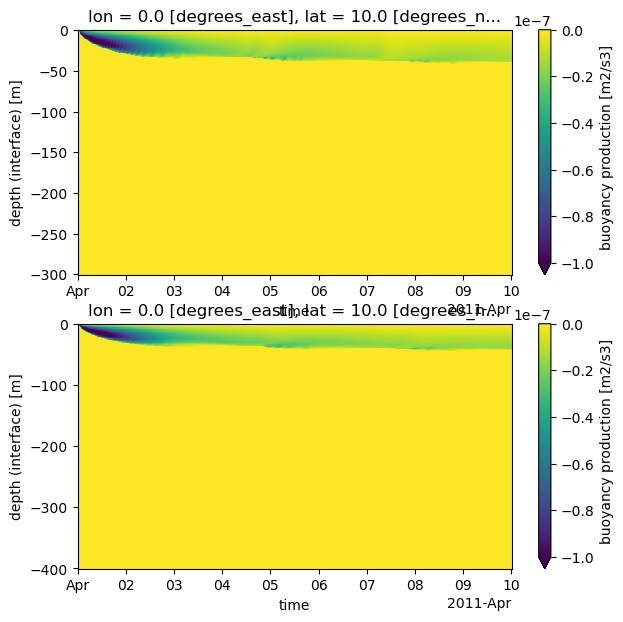

In [36]:
fig, ax = plt.subplots(2,1,figsize=(7,7))

ds_1.G.T.plot(ax=ax[0], vmin=-1e-7)
ds_2.G.T.plot(ax=ax[1], vmin=-1e-7)

plt.savefig("G_comp_initial_BL_depth.png", dpi=300)

In [37]:
m_star_dataset_1 = xr.open_dataset(f"{root_dir}/{training_set_name_1}_m_star_G.nc")
m_star_dataset_2 = xr.open_dataset(f"{root_dir}/{training_set_name_2}_m_star_G.nc")

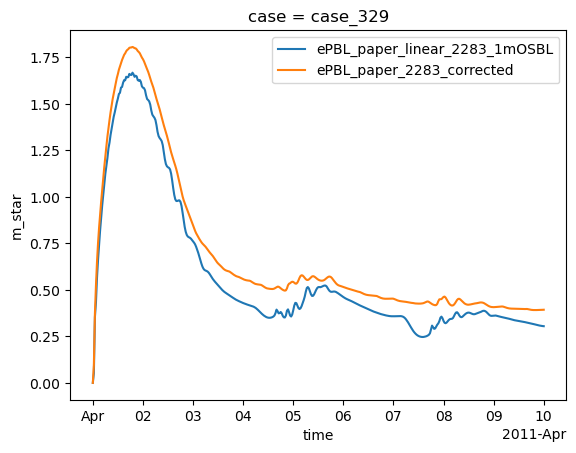

In [38]:
m_star_dataset_1.sel(case=case_1).m_star.plot(label=training_set_name_1)
m_star_dataset_2.sel(case=case_2).m_star.plot(label=training_set_name_2)
plt.legend()
plt.savefig("m_star_comp_initial_BL_depth.png", dpi=300)

In [39]:
bl_dataset_1 = xr.open_dataset(f"{root_dir}/{training_set_name_1}_bl.nc")
bl_dataset_2 = xr.open_dataset(f"{root_dir}/{training_set_name_2}_bl.nc")

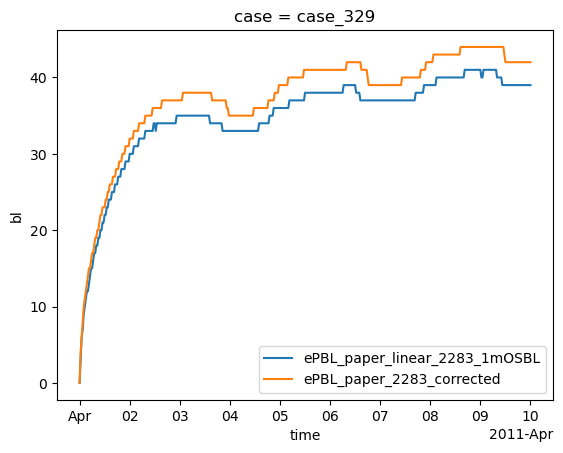

In [40]:
bl_dataset_1.sel(case=case_1).bl.plot(label=training_set_name_1)
bl_dataset_2.sel(case=case_2).bl.plot(label=training_set_name_2)
plt.legend()
plt.savefig("BL_comp_initial_BL_depth.png", dpi=300)

# SINGLE TRAINING SET ANALYSIS

In [11]:
training_set_name = "ePBL_paper_validation_2283_corrected"
root_dir = "/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set"

In [12]:
with open(f"{root_dir}/{training_set_name}_training_set_cases.json", "r") as file:
    gotm_case_dict = json.load(file)

In [13]:
feature_retreiver = FeatureRetreiver(
    training_set_dir=os.path.join(root_dir, f"{training_set_name}_training_dataset"),
    case_dict=gotm_case_dict
)

In [14]:
for case, specs in gotm_case_dict.items():
    if specs == {'lat': 10., 'tx': 0.1, 'heat_flux': -100., 'temp_grad': 0.001}:
        print(case) 
    else: pass

In [15]:
gotm_case_dict["case_4"]

{'temp_grad': 0.005, 'tx': 0.25, 'lat': 15.0, 'heat_flux': 10}

In [17]:
test_ds = xr.open_dataset(f"{root_dir}/{training_set_name}_training_dataset/case_4/output.nc").isel(lat=0, lon=0)

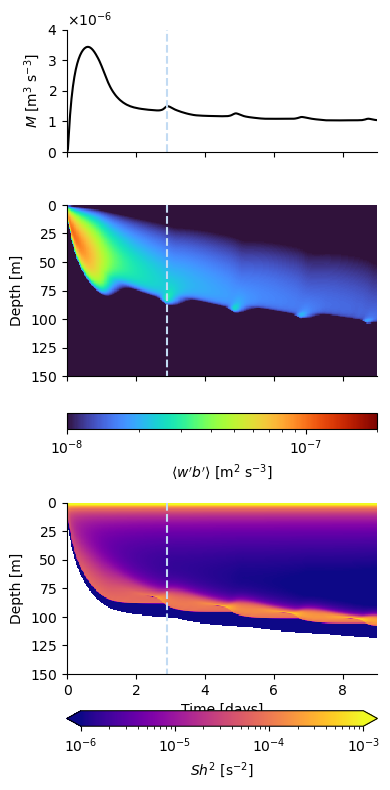

In [104]:
G = (test_ds.G*-1).T.values
time, depth, depth_i = test_ds.time.values, test_ds.z[0].values, test_ds.zi[0].values
time_days = np.linspace(0, 9, len(time)) 
M = (test_ds.G.sum(dim="zi")*-1).T.values
Sh2 = test_ds.SS.T.values
N2 = test_ds.NN.T.values

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(3,1, figsize=(4,8), tight_layout=True, sharex=True,
                       gridspec_kw={"height_ratios": [1, 2, 2]})

ax[0].plot(time_days, M, color="black")
ax[0].set_ylabel("$M$ [m$^3$ s$^{-3}$]")
ax[0].vlines(x=2.9, ymin=0, ymax=5e-6, linestyle="--", color="#c2dbf3")
ax[0].set_ylim(0, 4e-6)

c1 = ax[1].pcolor(time_days, -depth_i, G, norm=LogNorm(vmin=1e-8, vmax=2e-7), cmap="turbo")
plt.colorbar(c1, ax=ax[1], label="$\\langle w'b' \\rangle$ [m$^2$ s$^{-3}$]", orientation="horizontal", ticks=[1e-8, 1e-7])
ax[1].set_ylabel("Depth [m]")
ax[1].set_ylim(150,0)
ax[1].vlines(x=2.9, ymin=0, ymax=150, linestyle="--", color="#c2dbf3")

c2 = ax[2].pcolor(time_days, -depth_i, Sh2, norm=LogNorm(vmin=1e-6, vmax=1e-3), cmap="plasma")
plt.colorbar(c2, ax=ax[2], label="$Sh^2$ [s$^{-2}$]", orientation="horizontal", ticks=[1e-6, 1e-5, 1e-4, 1e-3], extend="both")
ax[2].set_ylim(150,0)
ax[2].vlines(x=2.9, ymin=0, ymax=150, linestyle="--", color="#c2dbf3")
ax[2].set_ylabel("Depth [m]")
ax[2].set_xlabel("Time [days]")

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.ticklabel_format(style='sci', useMathText=True, scilimits=(-3, 3), axis='y')

plt.savefig("case_4_G_M_Sh2.png", dpi=1500, transparent=True)

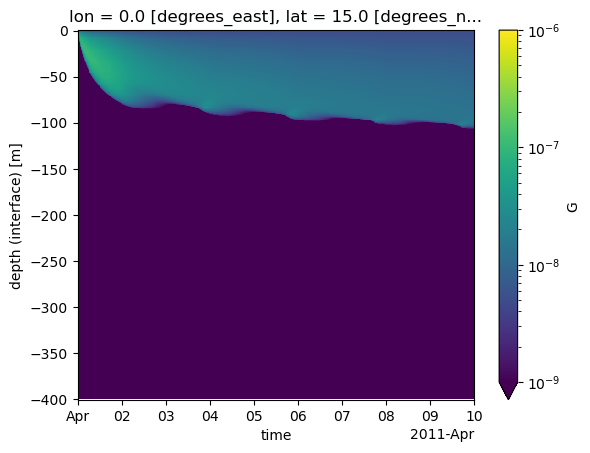

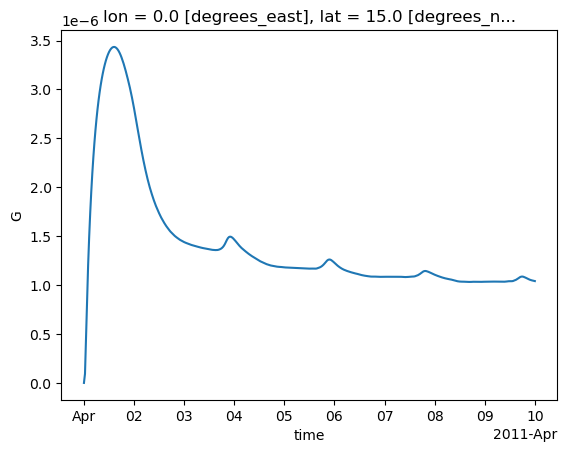

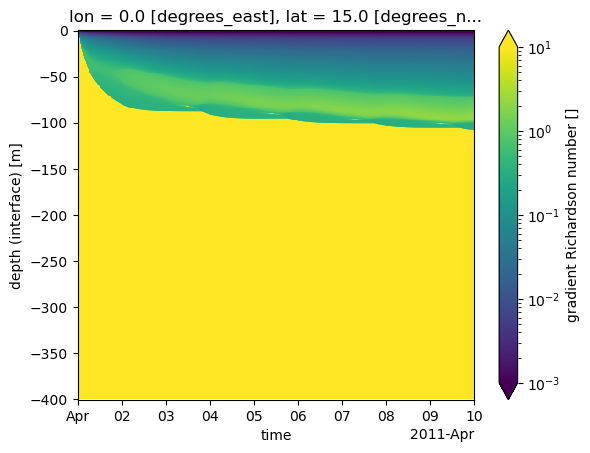

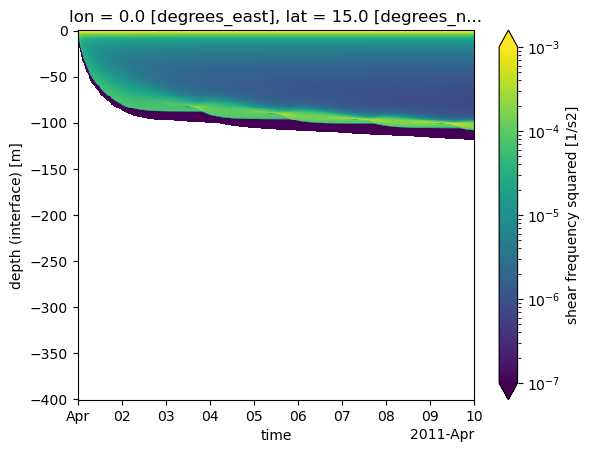

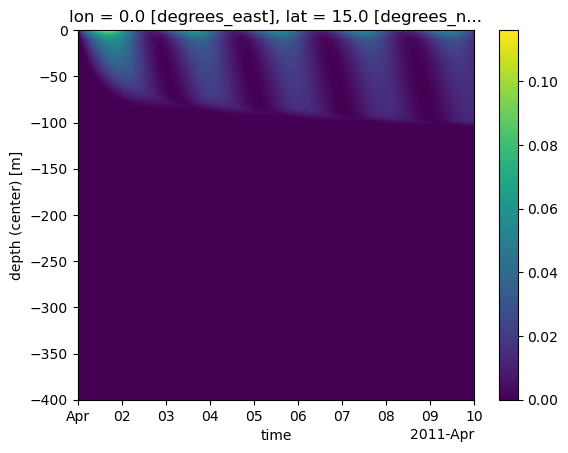

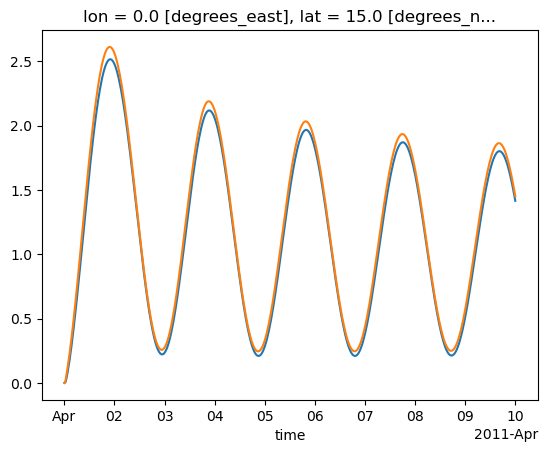

In [18]:
from matplotlib.colors import LogNorm

(test_ds.G*-1).T.plot(norm=LogNorm(vmin=1e-9, vmax=1e-6))
plt.figure()
(test_ds.G.sum(dim="zi")*-1).plot()
plt.figure()
test_ds.Rig.T.plot(norm=LogNorm(vmin=1e-3, vmax=10))
plt.figure()
test_ds.SS.T.plot(norm=LogNorm(vmin=1e-7, vmax=1e-3))
plt.figure()
(test_ds.u.T**2+test_ds.v.T**2).plot()
plt.figure()
((test_ds.u.T**2+test_ds.v.T**2).sum(dim='z')-(test_ds.u.isel(z=-1)**2+test_ds.v.isel(z=-1)**2)).plot()
((test_ds.u.T**2+test_ds.v.T**2).sum(dim='z')).plot()

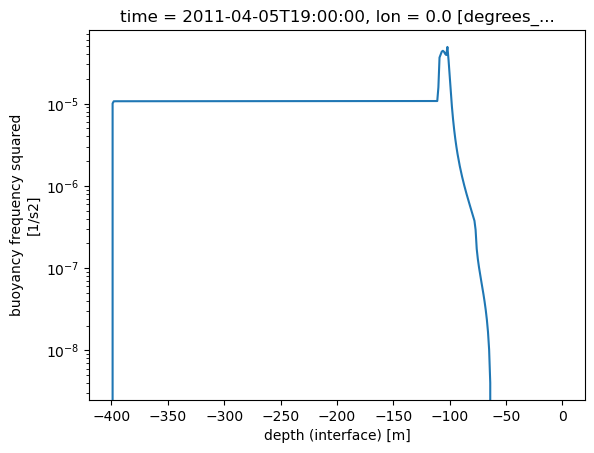

In [52]:
test_ds.NN[230].plot()
plt.gca().set_yscale("log")

In [49]:
zi_mask = np.where(test_ds['nuh'].values > 1e-6, test_ds['zi'].values, np.nan)
zi_vals = np.nanmin(zi_mask, axis=1)
zi_vals = np.where(np.isnan(zi_vals), -0.5, zi_vals)

/tmp/ipykernel_2761403/3782839414.py:2: RuntimeWarning: All-NaN slice encountered
  zi_vals = np.nanmin(zi_mask, axis=1)


In [28]:
test_ds['zi']

<xarray.DataArray 'zi' (time: 433, zi: 401)> Size: 695kB
[173633 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 3kB 2011-04-01 ... 2011-04-10
    lon      float32 4B 0.0
    lat      float32 4B 10.0
    zi       (time, zi) float32 695kB ...
Attributes:
    units:          m
    long_name:      depth (interface)
    standard_name:  ??
    path:           /column_structure
    cell_methods:   time: mean
    positive:       up
    axis:           Z

In [47]:
z_mask = np.where(test_ds['nuh'].values[:,:-1] > 1e-6, test_ds['z'].values, np.nan)
z_vals = np.nanmin(z_mask, axis=1)
z_vals = np.where(np.isnan(z_vals), -0.5, z_vals)

/tmp/ipykernel_2761403/3206522432.py:2: RuntimeWarning: All-NaN slice encountered
  z_vals = np.nanmin(z_mask, axis=1)


In [24]:
t, z = test_ds['u'].shape
u = test_ds['u'].values
v = test_ds['v'].values
z_grid = np.arange(z)[::-1]
z_mask = np.where(test_ds['nuh'].values[:,:-1] > 1e-6, z_grid, np.nan)
z_indices = np.nanmax(z_mask, axis=1)
z_indices = np.where(np.isnan(z_indices), 1, z_indices).astype(int)

/tmp/ipykernel_3516563/3177179060.py:6: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)


In [25]:
sh2 = test_ds['NN'].values

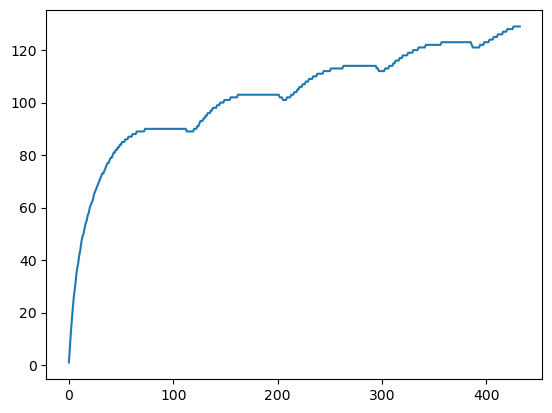

In [26]:
plt.plot(z_indices)

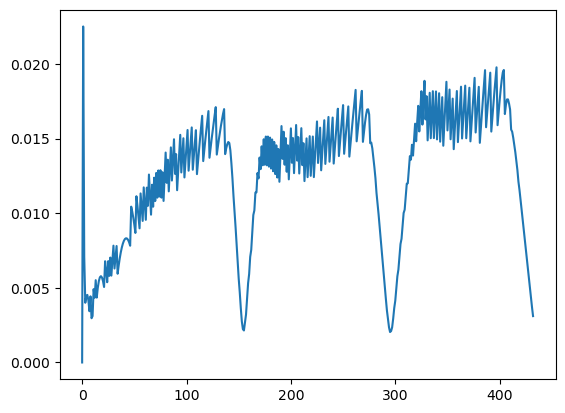

In [167]:
plt.plot(np.sqrt(u[np.arange(t),-z_indices+2]**2+v[np.arange(t),-z_indices+2]**2))

In [81]:
u[:,z_indices]

IndexError: arrays used as indices must be of integer (or boolean) type

In [57]:
test_ds['u'][:,z_vals]

TypeError: invalid indexer array, does not have integer dtype: array([  -0.5,   -4.5,   -9.5,  -14.5,  -18.5,  -22.5,  -26.5,  -30.5,
        -33.5,  -37.5,  -40.5,  -42.5,  -45.5,  -47.5,  -50.5,  -52.5,
        -54.5,  -56.5,  -58.5,  -60.5,  -62.5,  -64.5,  -65.5,  -67.5,
        -69.5,  -70.5,  -72.5,  -73.5,  -75.5,  -76.5,  -77.5,  -79.5,
        -80.5,  -81.5,  -83.5,  -84.5,  -85.5,  -86.5,  -87.5,  -88.5,
        -89.5,  -90.5,  -91.5,  -92.5,  -93.5,  -94.5,  -95.5,  -95.5,
        -96.5,  -97.5,  -98.5,  -99.5,  -99.5, -100.5, -101.5, -102.5,
       -102.5, -103.5, -104.5, -104.5, -105.5, -106.5, -106.5, -107.5,
       -107.5, -108.5, -109.5, -109.5, -110.5, -110.5, -111.5, -111.5,
       -112.5, -112.5, -113.5, -113.5, -114.5, -114.5, -115.5, -115.5,
       -115.5, -116.5, -116.5, -117.5, -117.5, -117.5, -118.5, -118.5,
       -118.5, -119.5, -119.5, -120.5, -120.5, -120.5, -120.5, -121.5,
       -121.5, -121.5, -122.5, -122.5, -122.5, -122.5, -123.5, -123.5,
       -123.5,

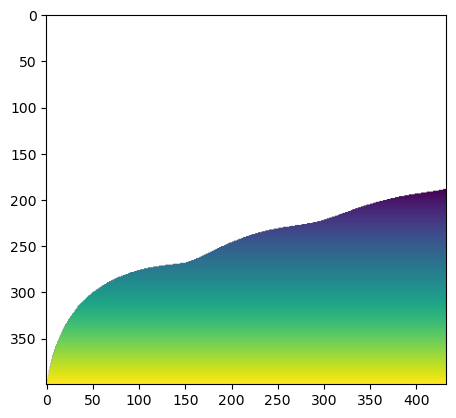

In [31]:
test_ds['nuh'].where('zi' == compute_bl_rh18(test_ds)[:,np.newaxis])

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)


<xarray.DataArray 'nuh' (time: 433, zi: 401)> Size: 695kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(433, 401), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2011-04-01 ... 2011-04-10
    lon      float32 4B 0.0
    lat      float32 4B 10.0
    zi       (time, zi) float32 695kB -400.0 -399.0 -398.0 ... -1.0 -5.258e-12
Attributes:
    units:          m2/s
    long_name:      turbulent diffusivity of heat
    standard_name:  ??
    path:           /turbulence
    cell_methods:   time: mean

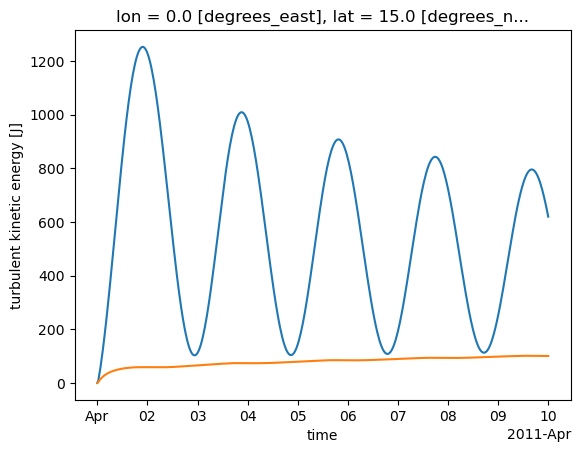

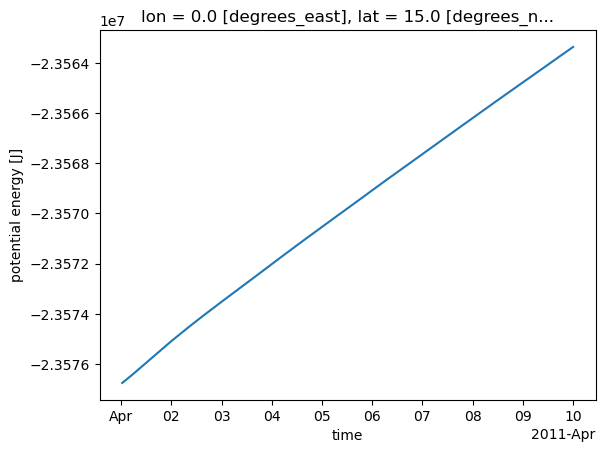

In [27]:
plt.figure()
test_ds.Ekin.plot()
test_ds.Eturb.plot()
plt.figure()
test_ds.Epot[1:].plot()

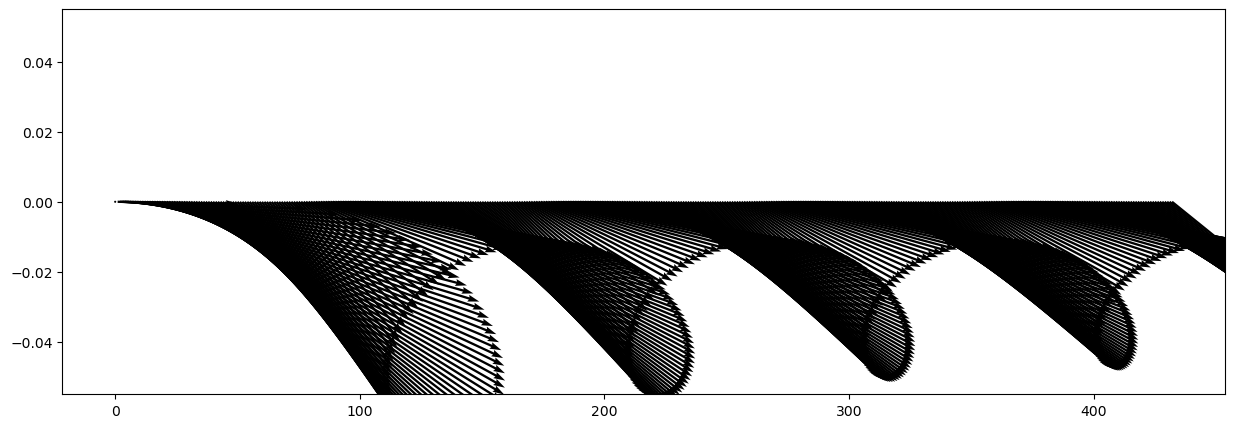

In [28]:
u, v = test_ds.u.isel(z=-1).values, test_ds.v.isel(z=-1).values

plt.figure(figsize=(15,5))
plt.quiver(np.arange(len(u)), 0, u, v, scale=1, width=0.002)

(0.0, 0.0001)

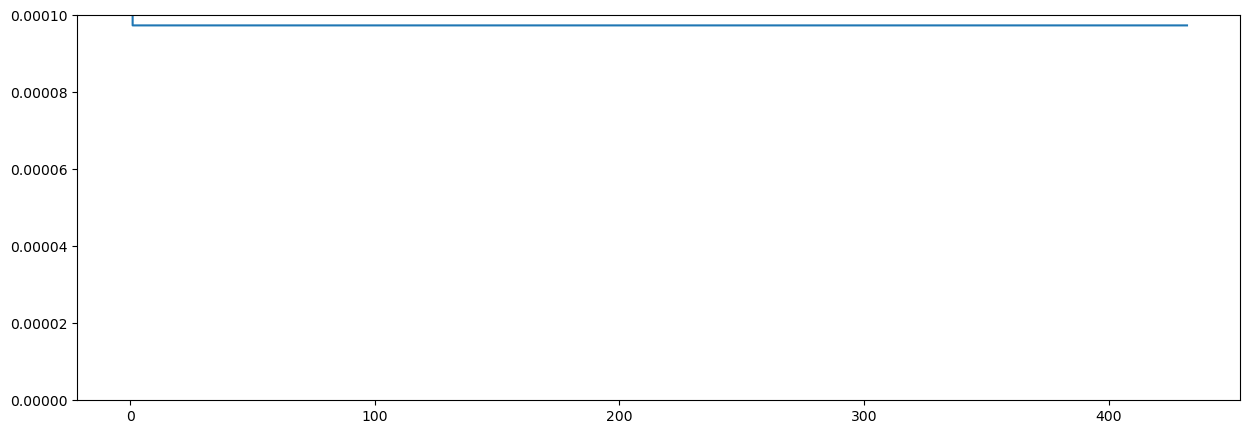

In [42]:
tx, ty = test_ds.tx.values, test_ds.ty.values

plt.figure(figsize=(15,5))
plt.plot(tx)
plt.ylim(0, 0.0001)

In [30]:
tau = np.sqrt(test_ds.tauy**2+test_ds.taux**2)

In [31]:
angle = np.arccos(u*tx/(np.sqrt(u**2+v**2)*tx))
magnitude = tx*np.sqrt(u**2+v**2)
time = test_ds.time.values
depth = test_ds.zi[0].values

fig, ax = plt.subplots(4,1,figsize=(10,10))

ax[0].set_ylabel(r"$\theta$ [rad]")
ax[0].plot(time,angle, color="black")
ax[1].set_ylabel(r"$|u||\tau|$ [m$^3$ s$^{-3}$]")
ax[1].plot(time, magnitude, color="black")
ax[2].set_ylabel(r"$u \cdot \tau$")
ax[2].plot(time, np.cos(angle)*magnitude, color="red", label=r"$|u||\tau|\cos(\theta)$")
ax[2].plot(time, u*tx, color="black", linestyle="dashed", label=r"$u_x\tau_x$")
ax[2].legend()
ax[3].contourf(time, depth, tau.T, 100)

fig.tight_layout()

NameError: name 'tx' is not defined

In [144]:
xs = np.arange(len(time))*1/20
ys = -(7/16*np.sin(xs) + 7/64*np.sin(2*xs) + 1/48*np.sin(3*xs) + 1/512*np.sin(4*xs))*np.exp(-1/20*xs)

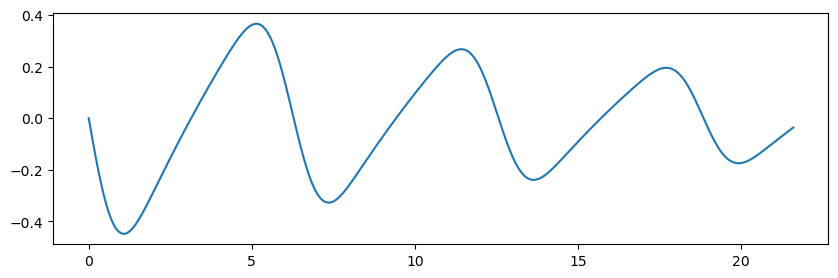

In [145]:
plt.figure(figsize=(10,3))
plt.plot(xs, ys)

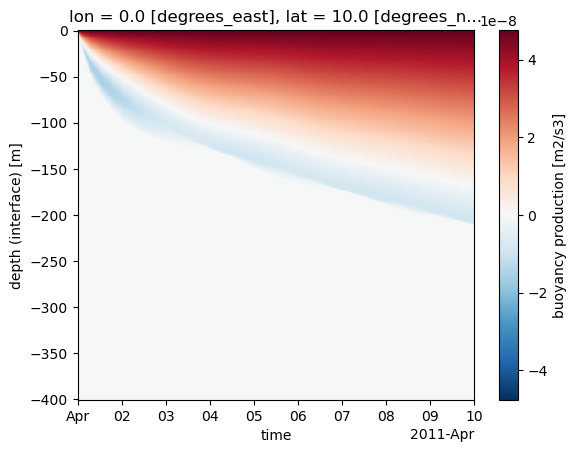

In [17]:
test_ds.G.T.plot()

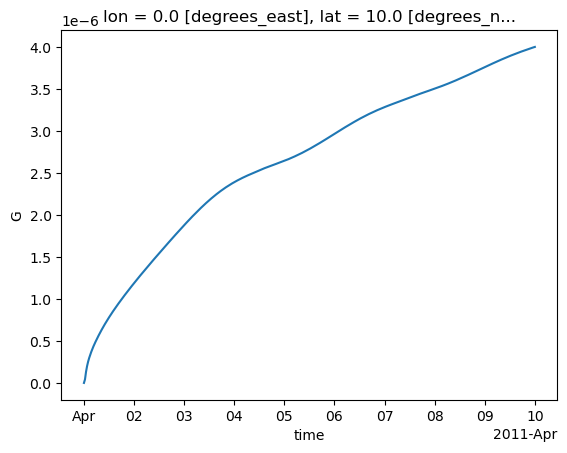

In [18]:
test_ds.G.where(test_ds.G > 0).sum(dim="zi").plot()

In [19]:
NN = test_ds.NN.where(test_ds.NN < 0)
nuh = test_ds.nuh.where(test_ds.NN < 0)

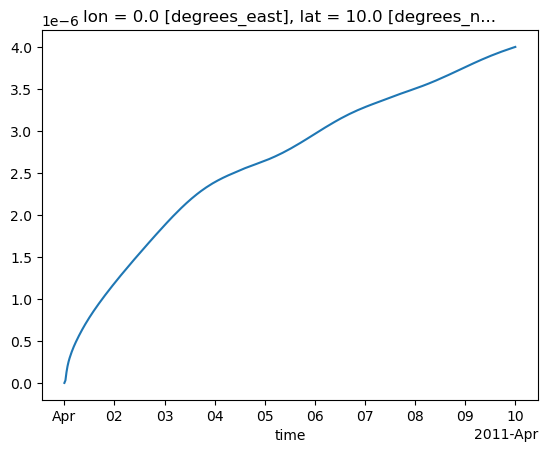

In [20]:
(-test_ds.NN.where(test_ds.NN < 0)*test_ds.nuh.where(test_ds.NN < 0)).sum(dim="zi", skipna=True).plot()

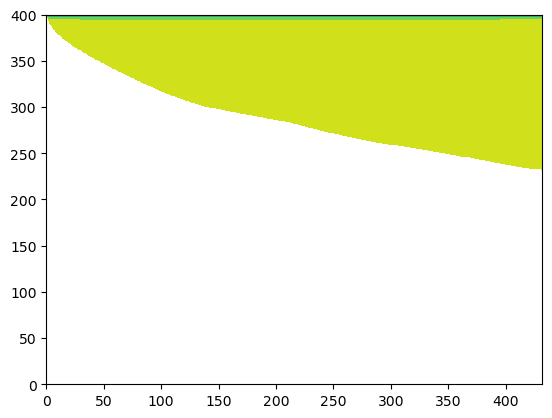

In [21]:
plt.contourf(NN.T)

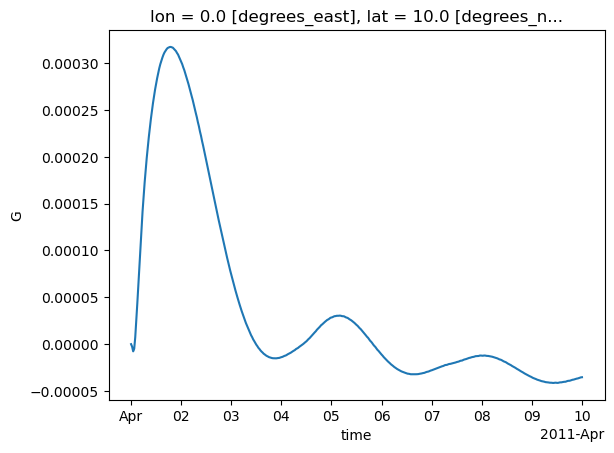

In [22]:
((-test_ds.G.where(test_ds.G < 0).sum(dim="zi") - 0.066*test_ds.G.where(test_ds.G > 0).sum(dim="zi"))/0.1**3).plot()

In [15]:
latitudes = np.array([case['lat'] for case in gotm_case_dict.values()])
wind_stresses = np.array([case['tx'] for case in gotm_case_dict.values()])
heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
temp_grads = np.array([case['temp_grad'] for case in gotm_case_dict.values()])

In [16]:
cases = np.arange(1,len(latitudes)+1)

In [ ]:
# this takes waaaay too long; need to optimize
# Actually, Qing says that gaea is simply very slow at analysis; we have to move it to PPAN
m_star_dataset = feature_retreiver.make_m_star_dataset()
m_star_dataset.to_netcdf(f"{root_dir}/{training_set_name}_m_star_G.nc")

In [17]:
bl_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=compute_bl_rh18,
    processing_method_name="bl",
    variable="nuh",
    coordinates=["time"]
)

# bl_dataset.to_netcdf(f"{root_dir}/{training_set_name}_bl_nuh_1e-3.nc")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:28: RuntimeWarning

In [18]:
u_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=surface_velocity,
    processing_method_name="u_surf",
    variable="u",
    coordinates=["time"]
)

In [38]:
u_dataset.to_netcdf(f"{root_dir}/{training_set_name}_u_surf.nc")

In [19]:
v_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=surface_velocity,
    processing_method_name="v_surf",
    variable="v",
    coordinates=["time"]
)

In [40]:
v_dataset.to_netcdf(f"{root_dir}/{training_set_name}_v_surf.nc")

In [20]:
M_dataset = feature_retreiver.make_M_dataset()
# M_dataset.to_netcdf(f"{root_dir}/{training_set_name}_M.nc")

In [21]:
u_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="u")
v_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="v")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feat

In [43]:
u_bl_dataset.to_netcdf(f"{root_dir}/{training_set_name}_u_bl.nc")
v_bl_dataset.to_netcdf(f"{root_dir}/{training_set_name}_v_bl.nc")

In [22]:
SS_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="SS")
NN_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="NN")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feat

In [45]:
SS_bl_dataset.to_netcdf(f"{root_dir}/{training_set_name}_SS_bl.nc")
NN_bl_dataset.to_netcdf(f"{root_dir}/{training_set_name}_NN_bl.nc")

In [23]:
u_bl_mean_dataset = feature_retreiver.make_var_across_bl_dataset(variable="u")
v_bl_mean_dataset = feature_retreiver.make_var_across_bl_dataset(variable="v")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feat

In [31]:
SS_bl_mean_dataset = feature_retreiver.make_var_across_bl_dataset(variable="SS")
NN_bl_mean_dataset = feature_retreiver.make_var_across_bl_dataset(variable="NN")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feat

In [17]:
SS_bl_dataset_0 = feature_retreiver.make_var_at_bl_dataset(variable="SS", index_above_bl=0)
NN_bl_dataset_0 = feature_retreiver.make_var_at_bl_dataset(variable="NN", index_above_bl=0)
SS_bl_dataset_1 = feature_retreiver.make_var_at_bl_dataset(variable="SS", index_above_bl=1)
NN_bl_dataset_1 = feature_retreiver.make_var_at_bl_dataset(variable="NN", index_above_bl=1)
SS_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="SS")
NN_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="NN")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:198: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feat

In [18]:
SS_mean_bl_dataset_1 = feature_retreiver.make_var_across_bl_dataset(variable="SS", index_above_bl=1, index_below_bl=1)
NN_mean_bl_dataset_1 = feature_retreiver.make_var_across_bl_dataset(variable="NN", index_above_bl=1, index_below_bl=1)
SS_bl_dataset_2 = feature_retreiver.make_var_across_bl_dataset(variable="SS", index_above_bl=2, index_below_bl=0)
NN_bl_dataset_2 = feature_retreiver.make_var_across_bl_dataset(variable="NN", index_above_bl=2, index_below_bl=0)

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:236: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feat

In [40]:
SS_bl_dataset_2.to_netcdf(f"{root_dir}/{training_set_name}_SS_bl_avg.nc")
NN_bl_dataset_2.to_netcdf(f"{root_dir}/{training_set_name}_NN_bl_avg.nc")

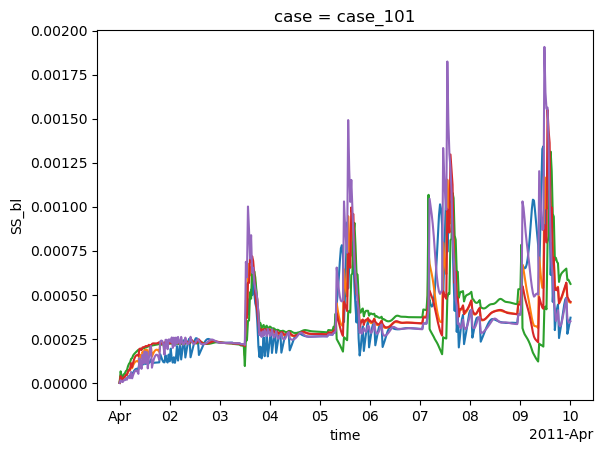

In [39]:
i=100
SS_mean_bl_dataset_1.SS_bl_mean.isel(case=i).plot()
SS_bl_dataset_2.SS_bl_mean.isel(case=i).plot()
SS_bl_dataset.SS_bl.isel(case=i).plot()
SS_bl_dataset_1.SS_bl.isel(case=i).plot()
SS_bl_dataset_0.SS_bl.isel(case=i).plot()

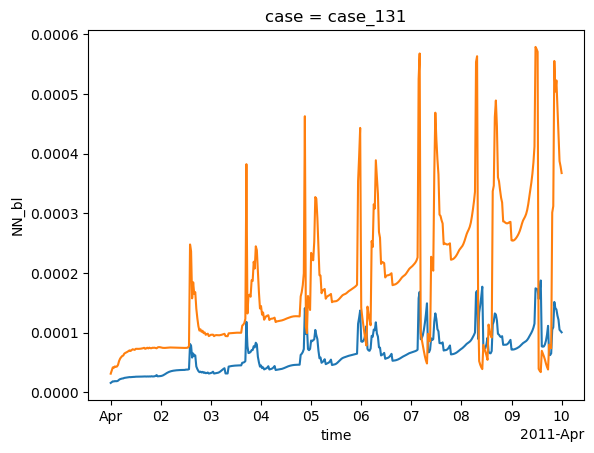

In [77]:
i=130
NN_bl_mean_dataset.NN_bl_mean.isel(case=i).plot()
NN_bl_dataset.NN_bl.isel(case=i).plot()
# NN_bl_dataset_1.NN_bl.isel(case=i).plot()
# NN_bl_dataset_0.NN_bl.isel(case=i).plot()

In [41]:
test_ds['u']

NameError: name 'test_ds' is not defined

In [18]:
m_star_dataset = xr.open_dataset(f"{root_dir}/{training_set_name}_m_star_G.nc")
bl_dataset = xr.open_dataset(f"{root_dir}/{training_set_name}_bl.nc")

In [19]:
bl_dataset_old = xr.open_dataset(f"{root_dir}/{training_set_name}_bl.nc")

In [25]:
i = 10

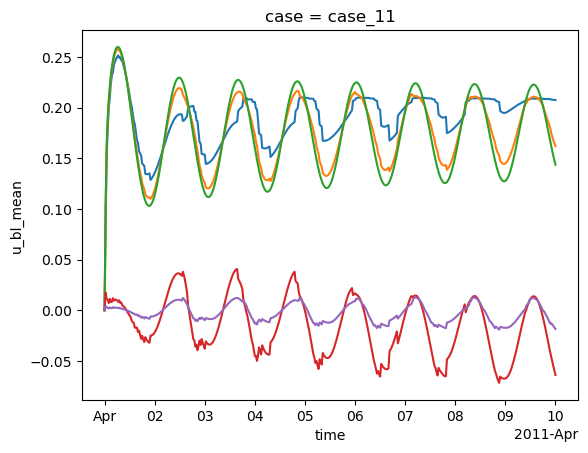

In [27]:
(u_dataset.isel(case=i).u_surf-u_bl_dataset.isel(case=i).u_bl).plot()
(u_dataset.isel(case=i).u_surf-u_bl_mean_dataset.isel(case=i).u_bl_mean).plot()
u_dataset.isel(case=i).u_surf.plot()
u_bl_dataset.isel(case=i).u_bl.plot()
u_bl_mean_dataset.isel(case=i).u_bl_mean.plot()

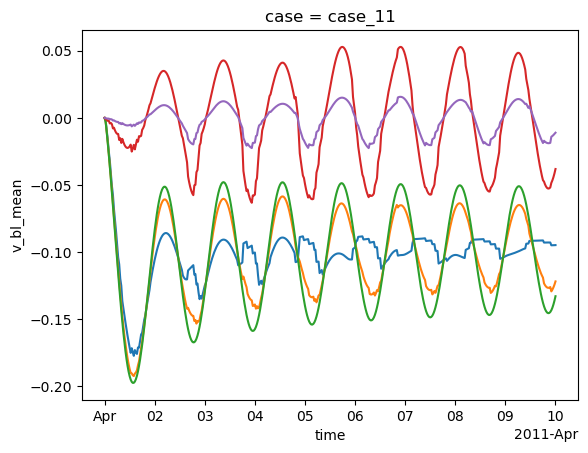

In [30]:
(v_dataset.isel(case=i).v_surf-v_bl_dataset.isel(case=i).v_bl).plot()
(v_dataset.isel(case=i).v_surf-v_bl_mean_dataset.isel(case=i).v_bl_mean).plot()
v_dataset.isel(case=i).v_surf.plot()
v_bl_dataset.isel(case=i).v_bl.plot()
v_bl_mean_dataset.isel(case=i).v_bl_mean.plot()

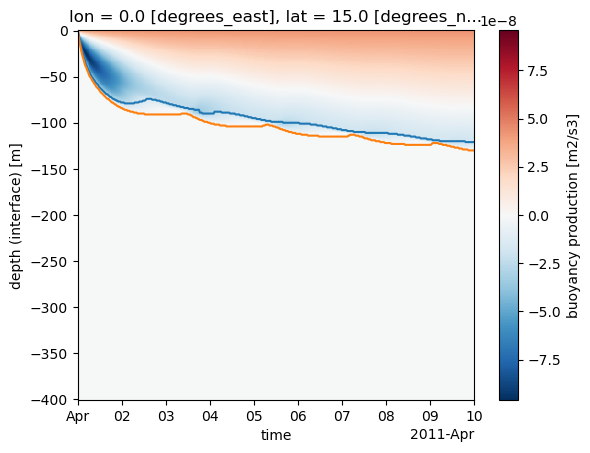

In [34]:
(-1*bl_dataset.isel(case=0).bl).plot()
(-1*bl_dataset_old.isel(case=0).bl).plot()
test_ds.G.T.plot()

##### $m_*$ and $H_{bl}$ sel method: last datapoint

In [17]:
last_m_star = m_star_dataset.m_star.values[:,-1]
last_bl = bl_dataset.bl.values[:,-1]

##### $m_*$ and $H_{bl}$ sel method: rolling average

In [46]:
m_stars = []
bls = []
Ms = []

dt = 1800
last_day_index = int(24 * 60 * 60 / dt)

for i in cases:
    m_star_rolling_avg = calculate_rolling_average(
        case=f"case_{i}",
        dataset=m_star_dataset,
        variable='m_star',
        case_dict=gotm_case_dict,
        dt=dt
    )

    m_stars.append(np.nanmean(m_star_rolling_avg[-last_day_index:-1]))

    bl_rolling_avg = calculate_rolling_average(
        case=f"case_{i}",
        dataset=bl_dataset,
        variable='bl',
        case_dict=gotm_case_dict,
        dt=dt
    )

    bls.append(np.nanmean(bl_rolling_avg[-last_day_index:-1]))

    M_rolling_avg = calculate_rolling_average(
        case=f"case_{i}",
        dataset=M_dataset,
        variable='M',
        case_dict=gotm_case_dict,
        dt=dt
    )

    Ms.append(np.nanmean(M_rolling_avg[-last_day_index:-1]))


m_stars = np.array(m_stars)
bls = np.array(bls)
Ms = np.array(Ms)

In [47]:
np.save(f"{root_dir}/{training_set_name}_mean_m_stars.npy", m_stars)
np.save(f"{root_dir}/{training_set_name}_mean_bls.npy", bls)
np.save(f"{root_dir}/{training_set_name}_mean_Ms.npy", Ms)

/tmp/ipykernel_3018414/3436184544.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,3))


ValueError: x and y must have same first dimension, but have shapes (433,) and (432,)

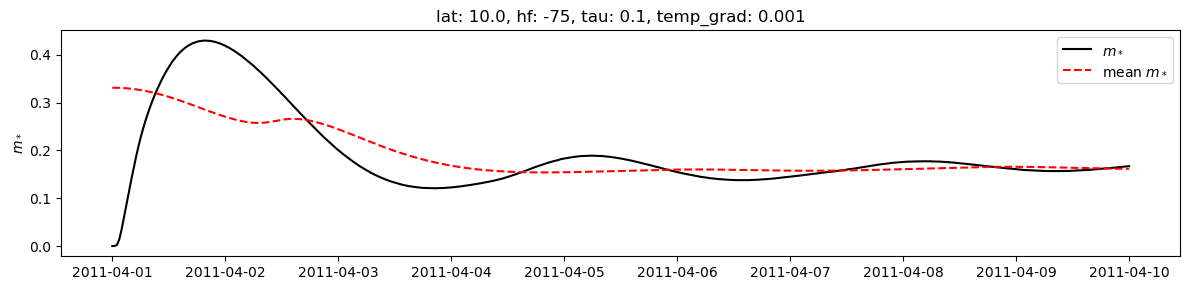

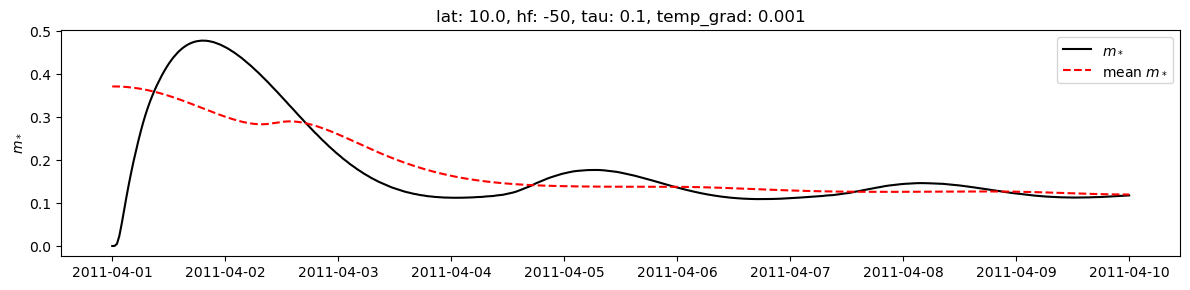

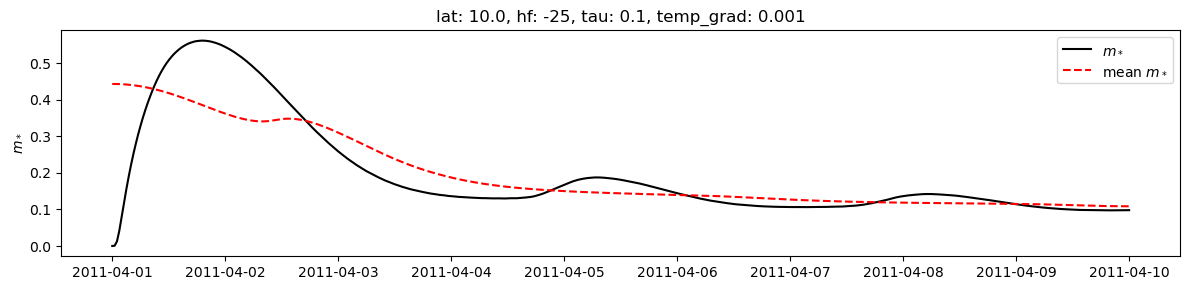

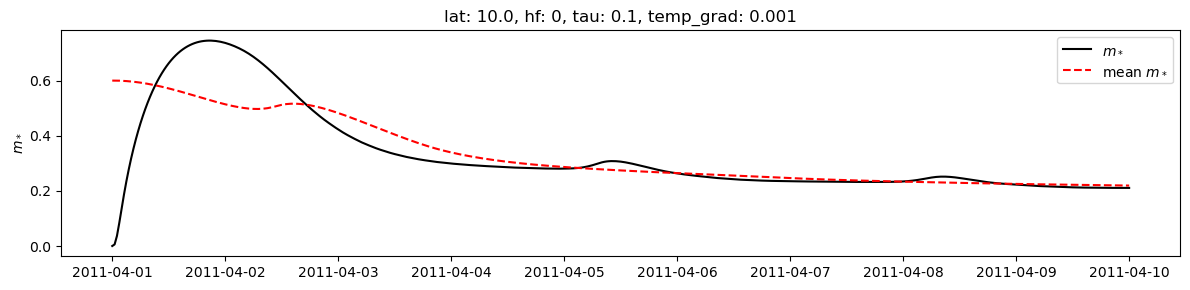

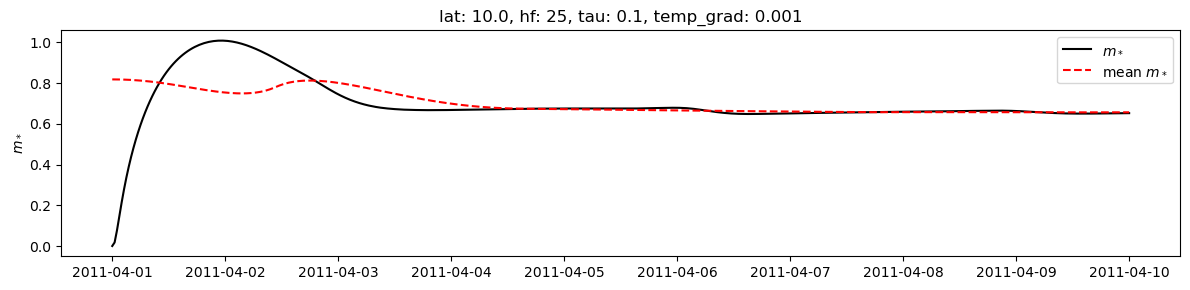

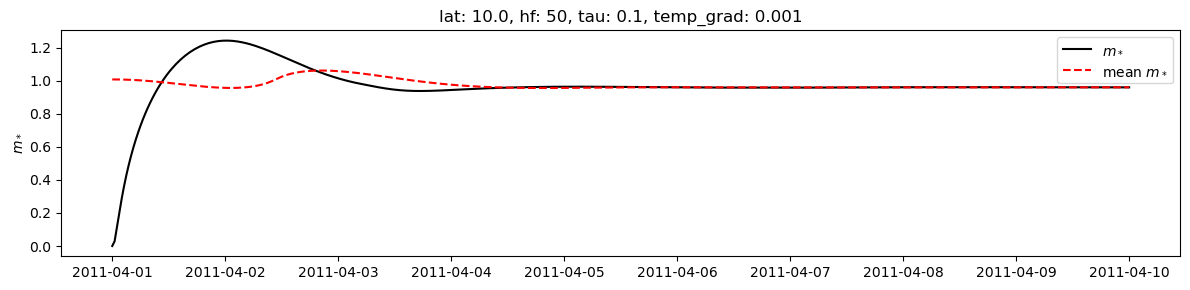

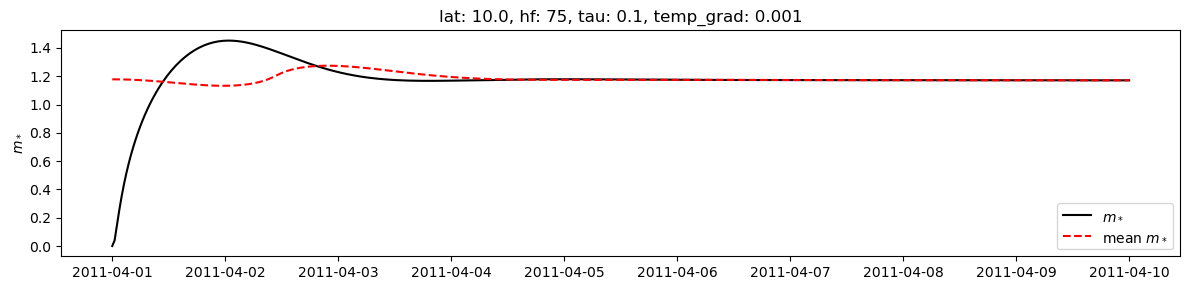

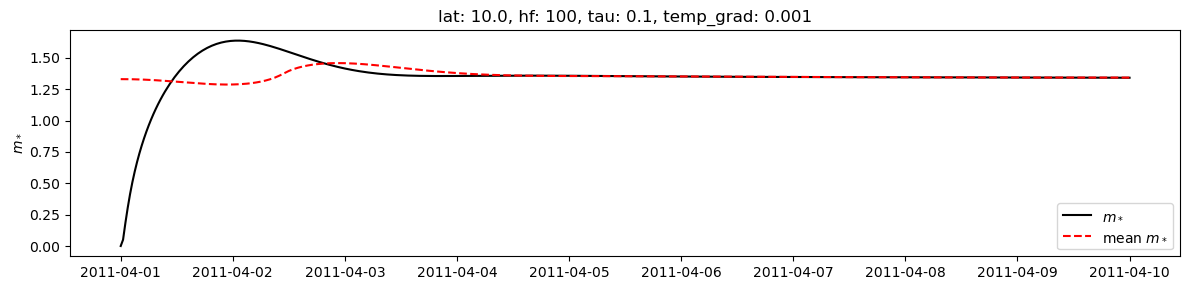

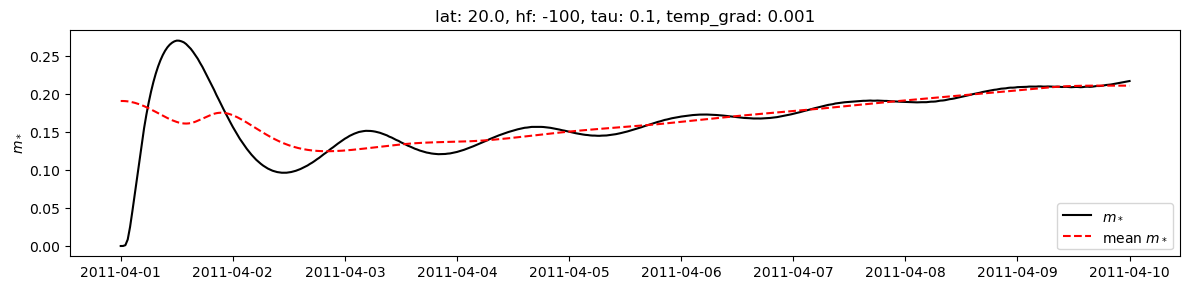

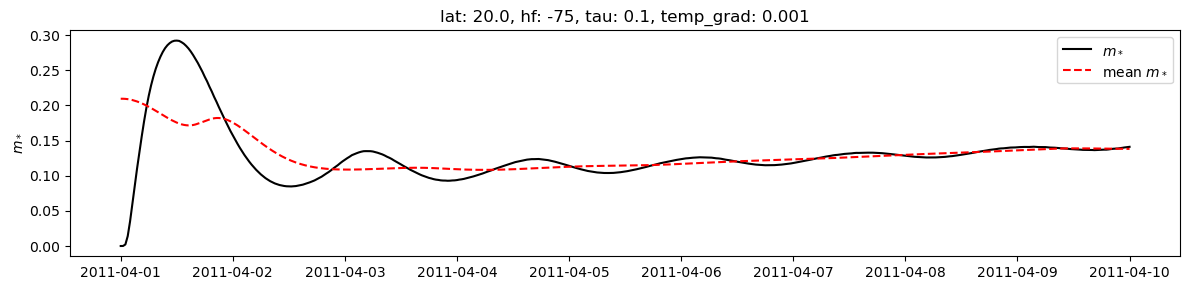

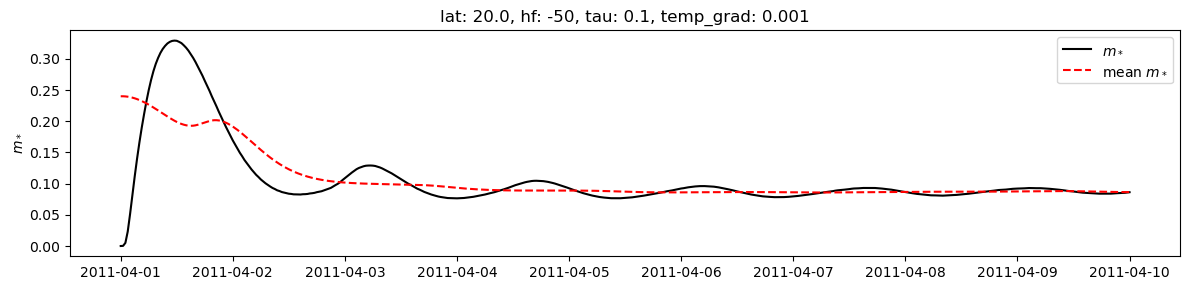

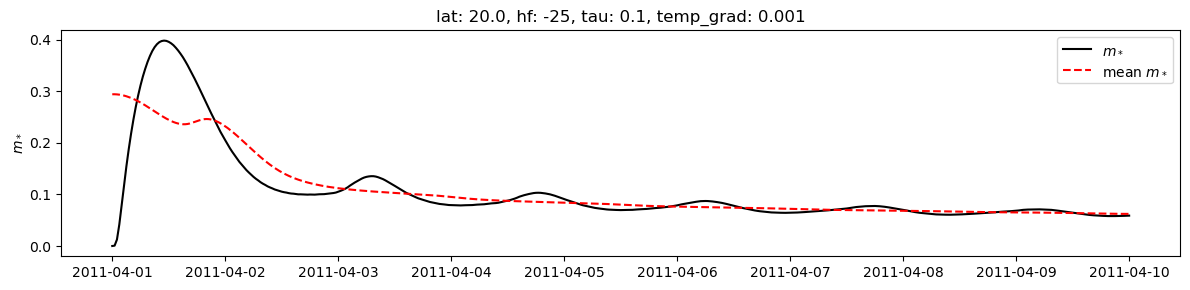

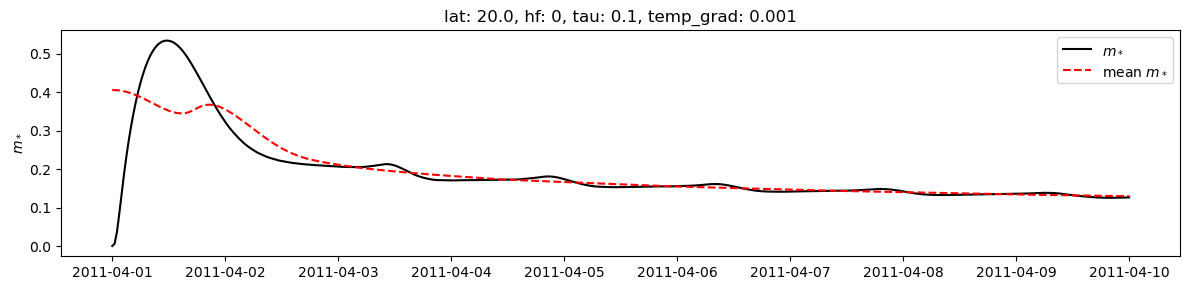

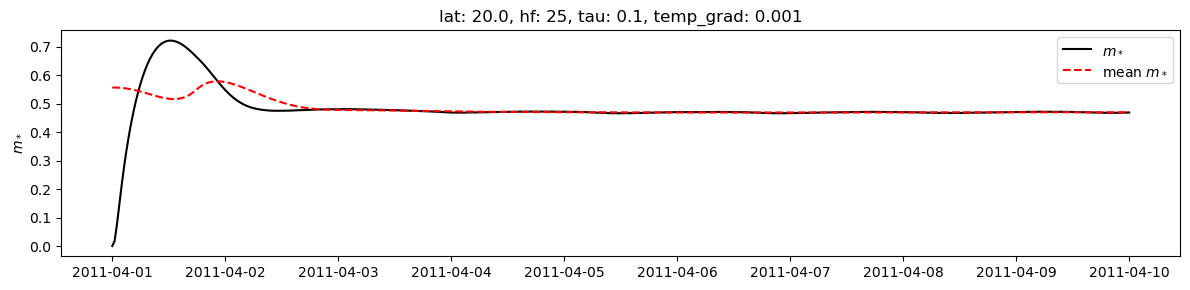

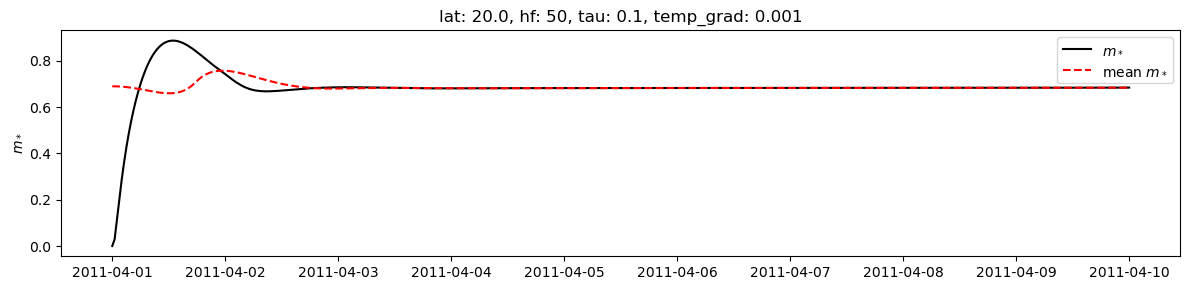

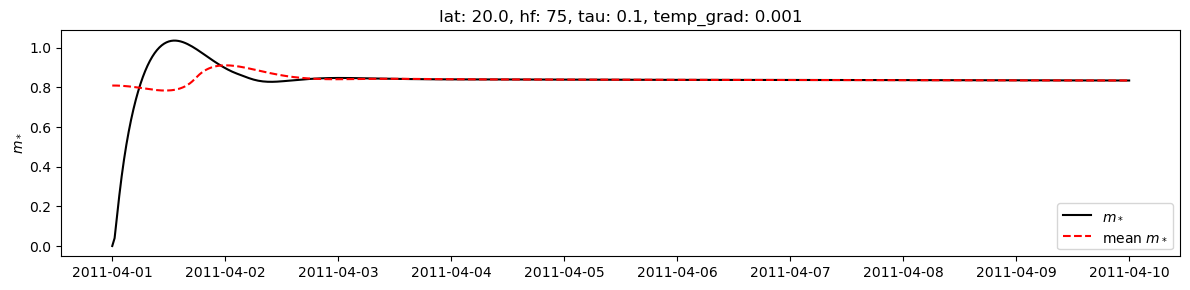

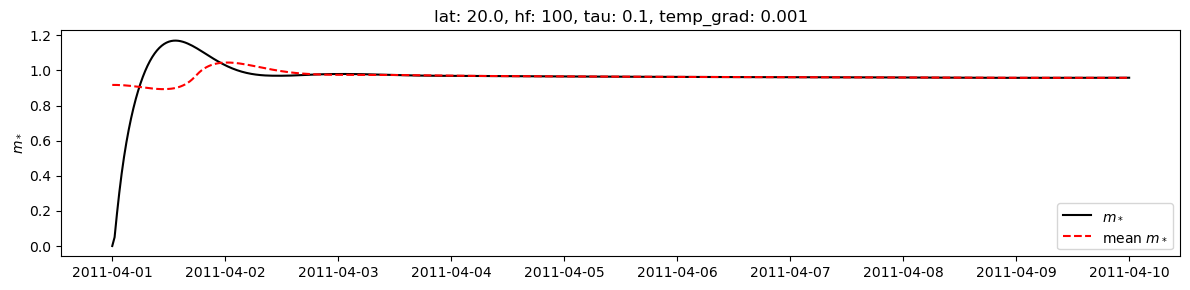

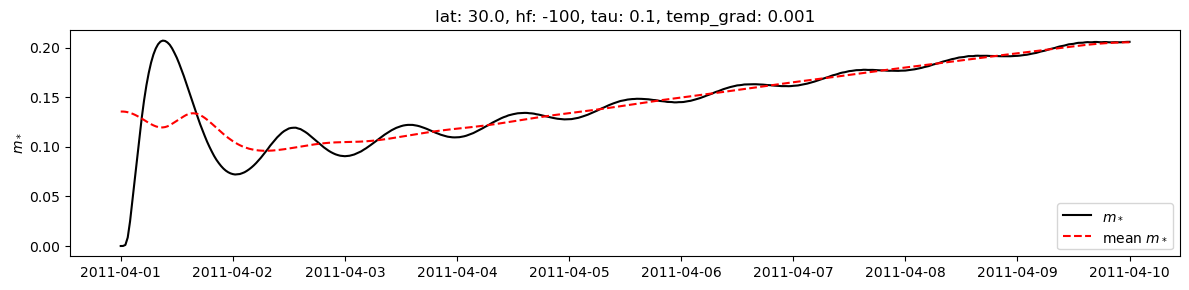

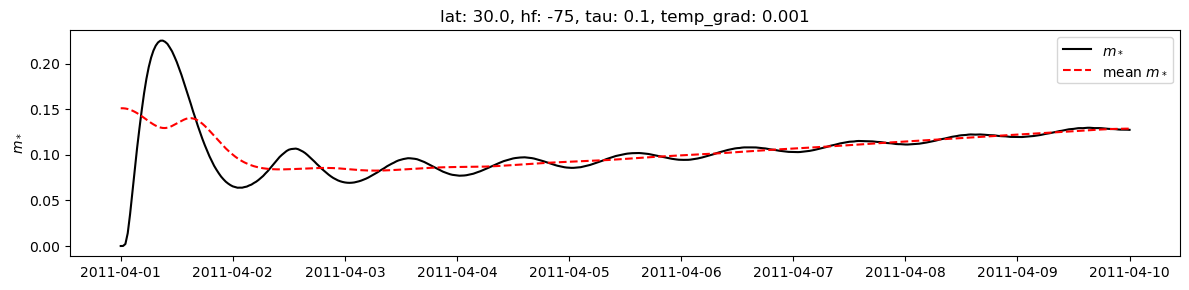

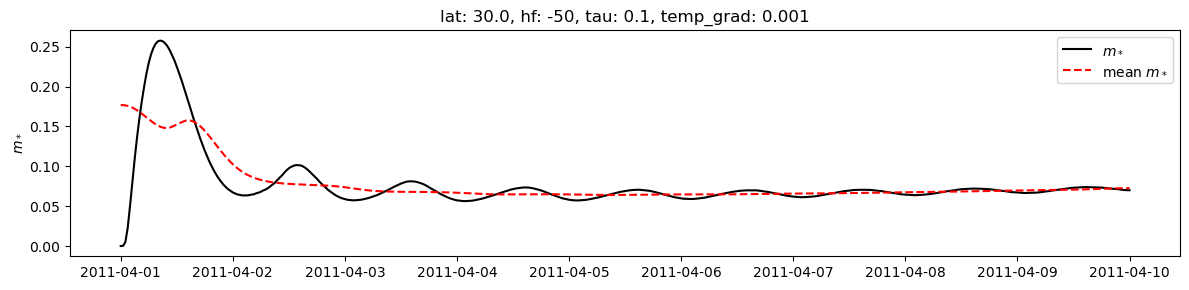

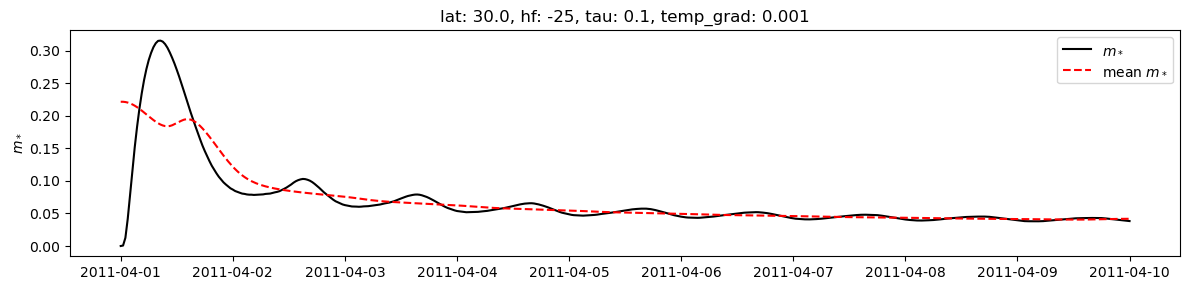

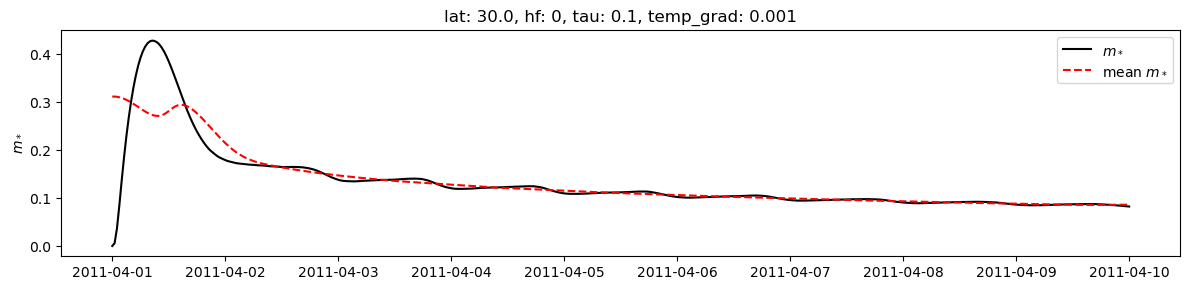

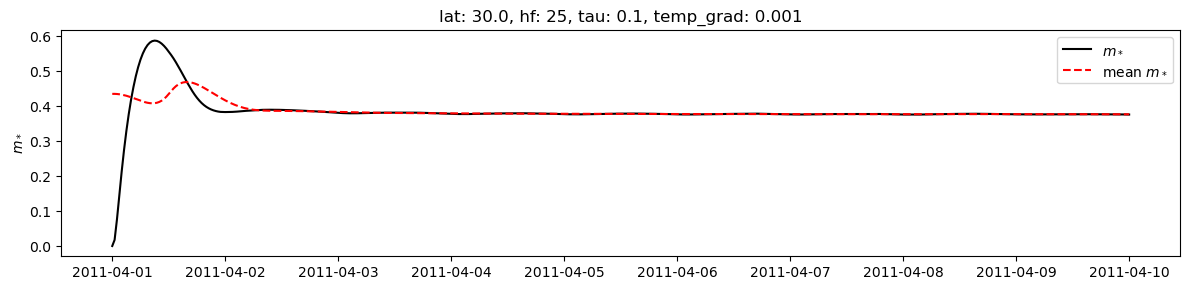

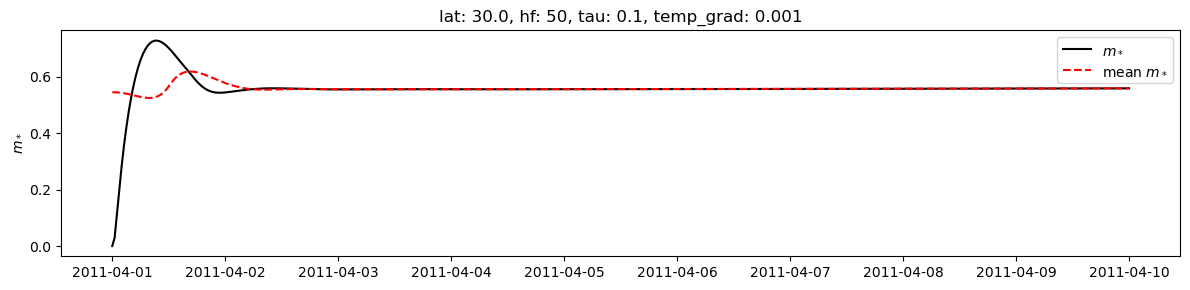

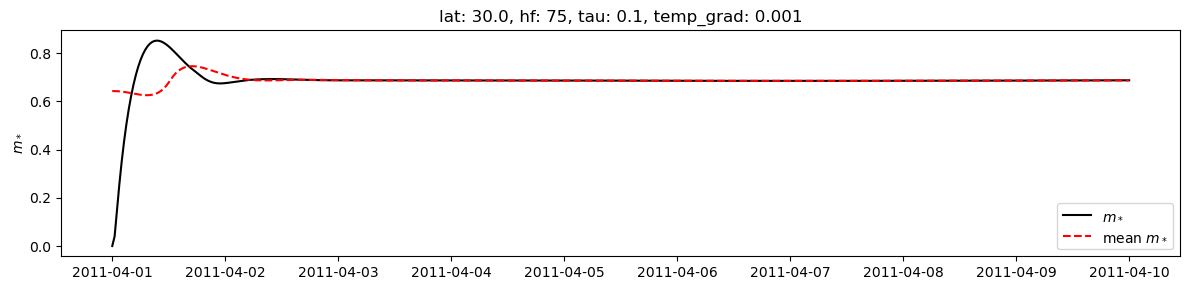

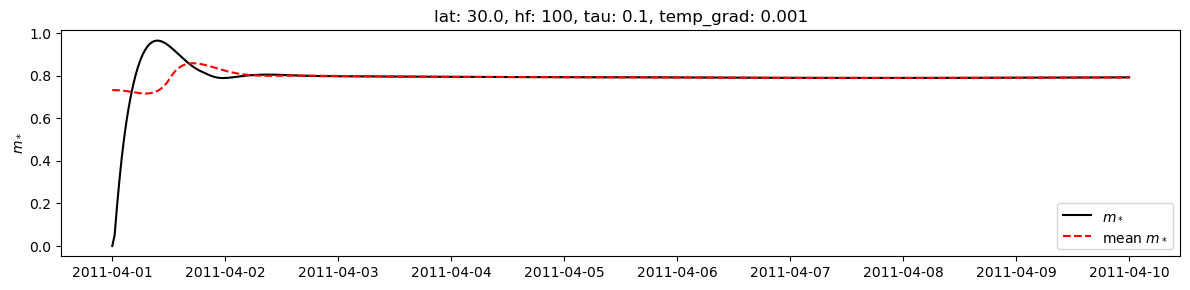

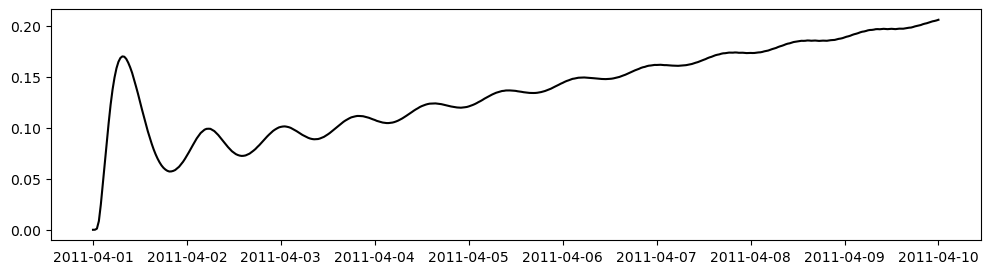

In [30]:
save = False

for i in range(1,60):
    m_star_rolling_avg = calculate_rolling_average(
        case=f"case_{i+1}",
        dataset=m_star_dataset,
        variable='m_star',
        case_dict=gotm_case_dict,
        dt=dt
    )

    plt.figure(figsize=(12,3))
    plt.plot(m_star_dataset.time.values, m_star_dataset.m_star.values[i,:], color="black",
             label="$m_*$")
    plt.plot(m_star_dataset.time.values, m_star_rolling_avg, 
             color="red", linestyle="dashed", label="mean $m_*$")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/m_star_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}_hf_{hf}.png", dpi=300)

##### $m_*$ and $H_{bl}$ sel method: mean over inertial period

In [134]:
data_list = [m_stars, mlds, wind_stresses, heat_fluxes, temp_grads, latitudes]
data_namelist = ["m_star", "mld", "tau", "hf", "t_grad", "lat"]

In [135]:
m_stars, m_star_variances = calculate_mean_over_inertial_period(
    data=m_star_dataset.m_star.values,
    latitudes=latitudes,
    dt=1800
)

/tmp/ipykernel_2727896/3495655317.py:21: RuntimeWarning: Mean of empty slice
  average[n_chunks], variance[n_chunks] = np.nanmean(array[end:]), np.nanstd(array[end:]) ** 2
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/miniconda/envs/scientific_python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2727896/3495655317.py:20: RuntimeWarning: Mean of empty slice
  average[j], variance[j] = np.nanmean(array[start:end]), np.nanstd(array[start:end]) ** 2


In [136]:
bls, bl_variances = calculate_mean_over_inertial_period(
    data=bl_dataset.bl.values,
    latitudes=latitudes,
    dt=1800
)

/tmp/ipykernel_2727896/3495655317.py:21: RuntimeWarning: Mean of empty slice
  average[n_chunks], variance[n_chunks] = np.nanmean(array[end:]), np.nanstd(array[end:]) ** 2
/tmp/ipykernel_2727896/3495655317.py:20: RuntimeWarning: Mean of empty slice
  average[j], variance[j] = np.nanmean(array[start:end]), np.nanstd(array[start:end]) ** 2


/tmp/ipykernel_2727896/1080153129.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,3))


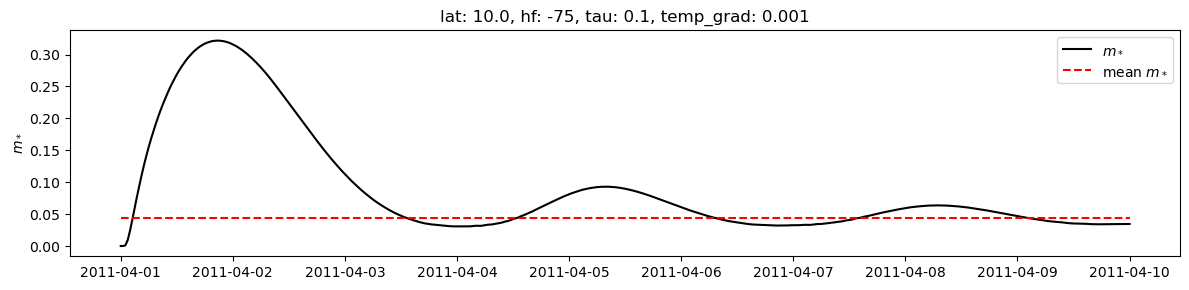

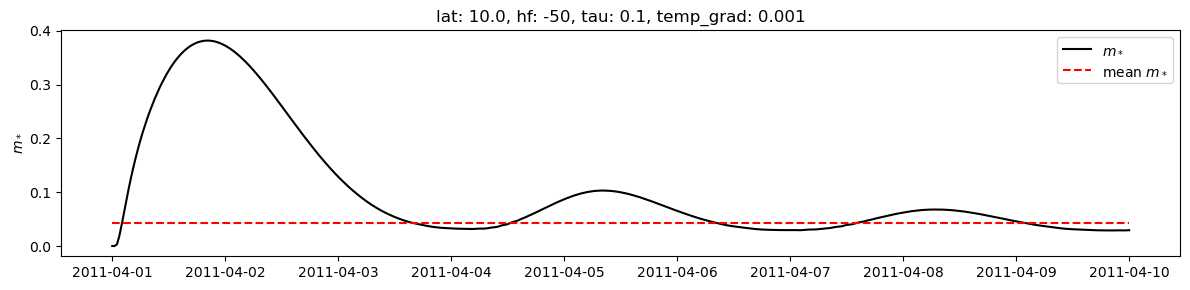

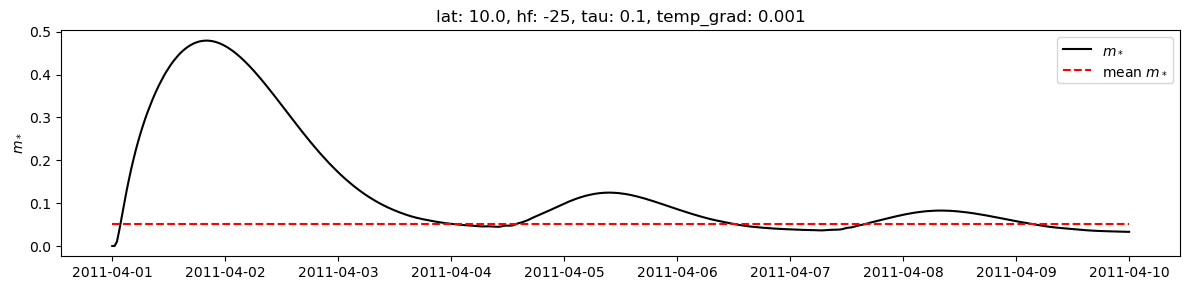

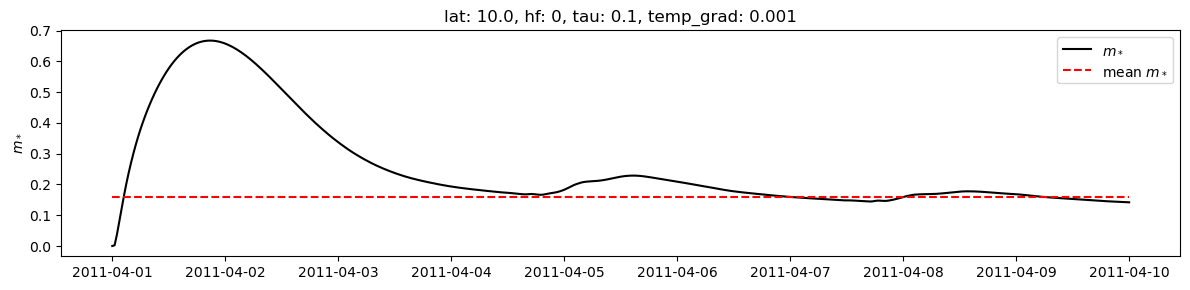

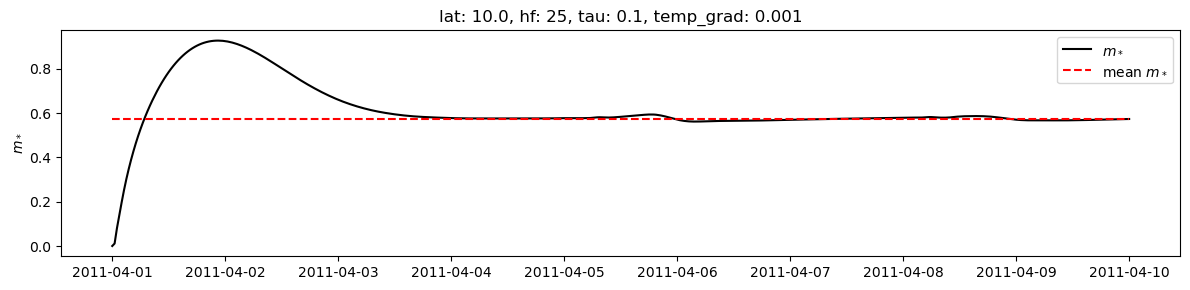

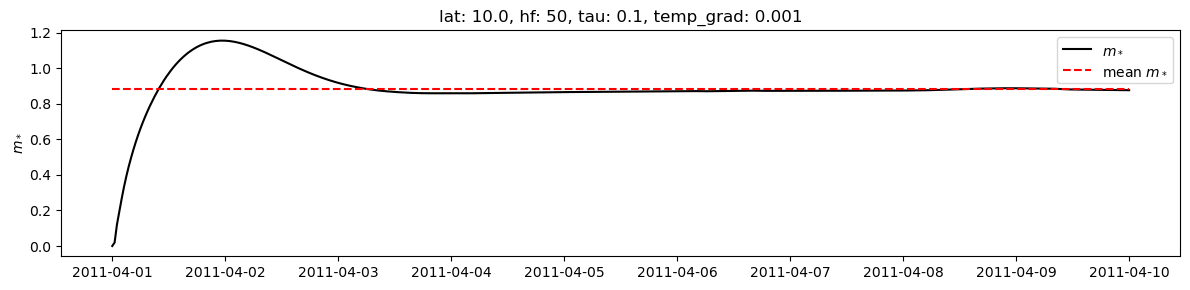

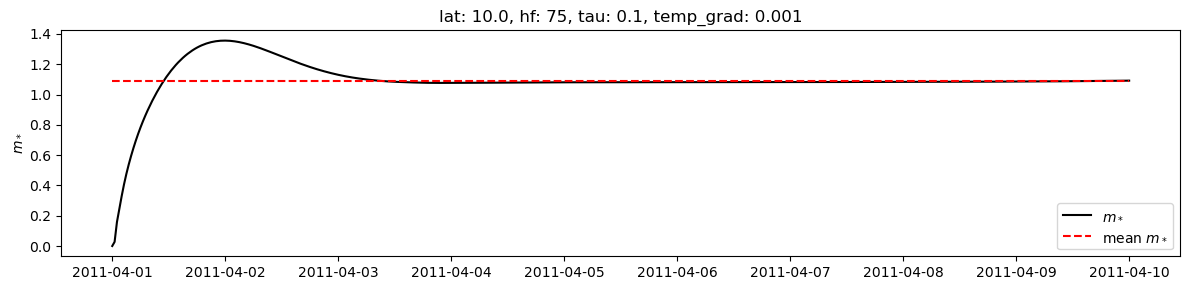

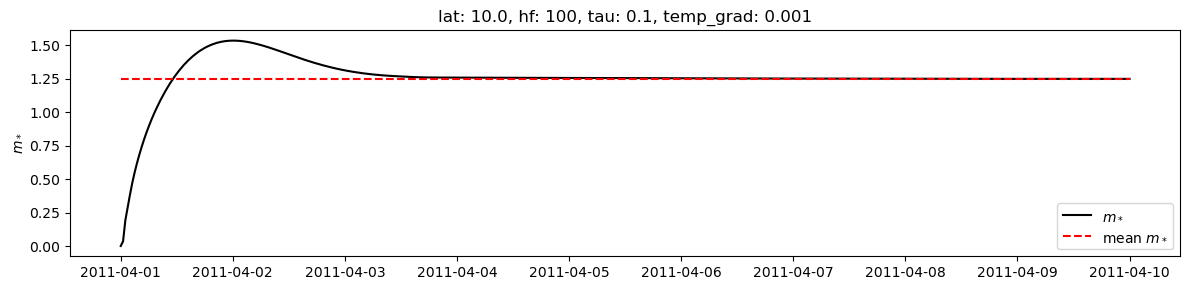

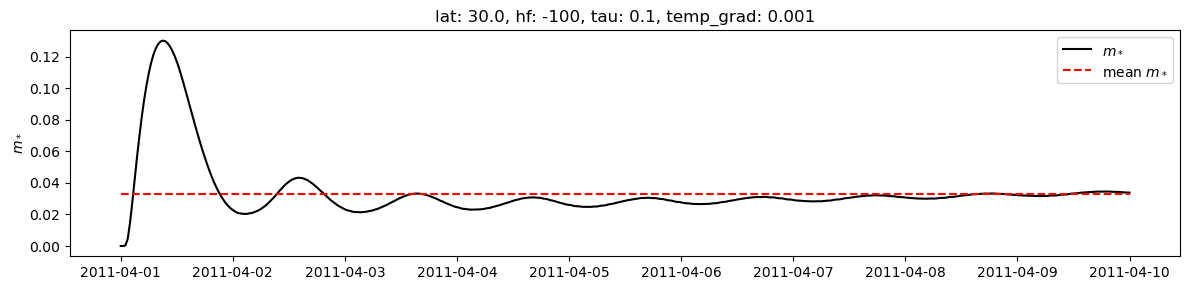

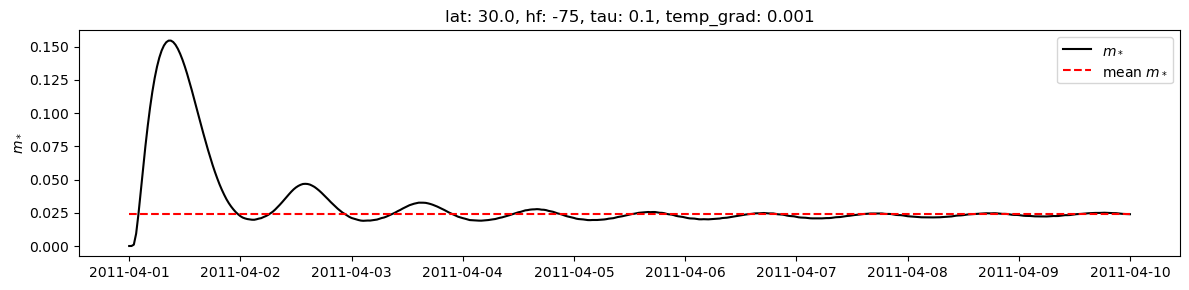

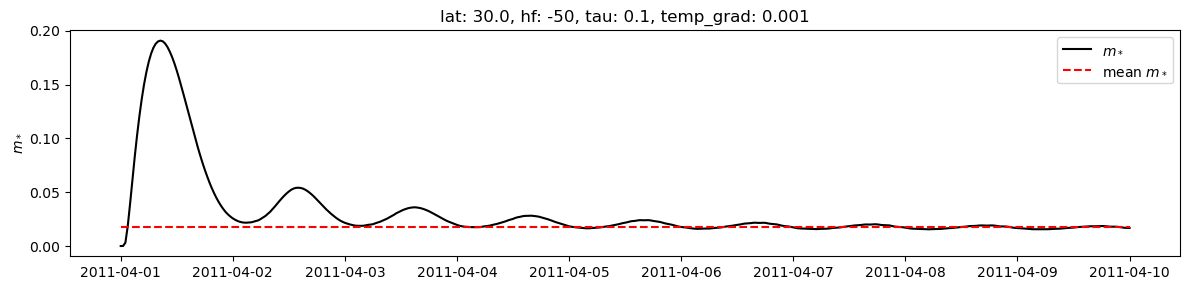

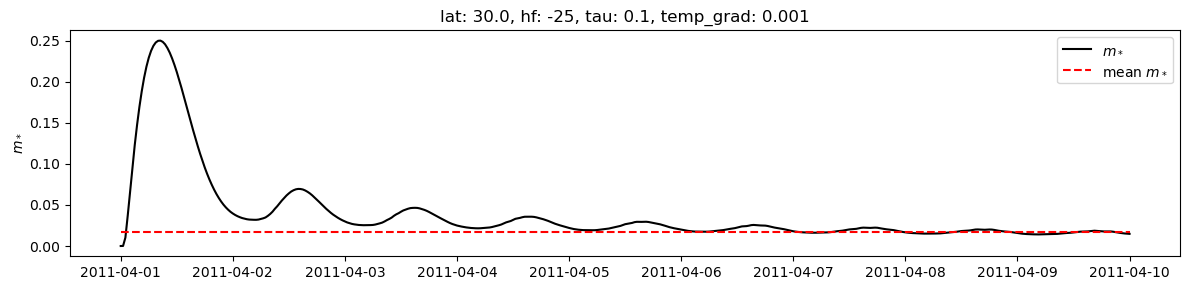

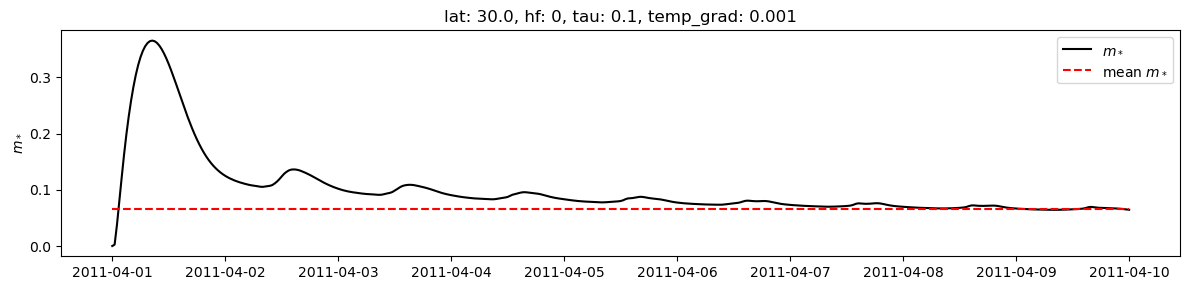

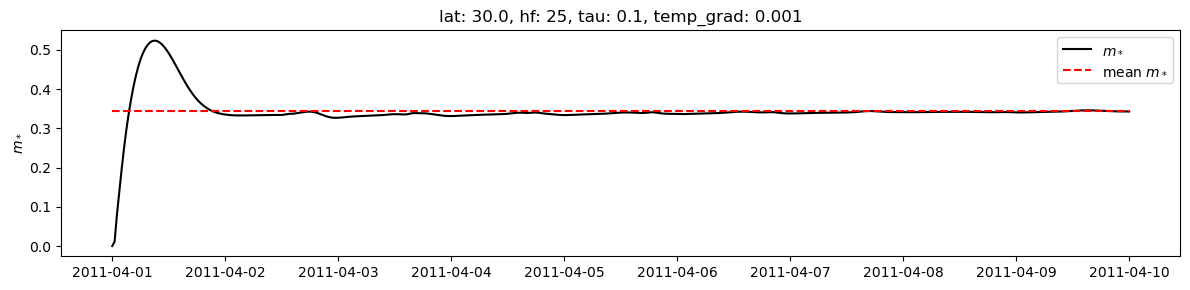

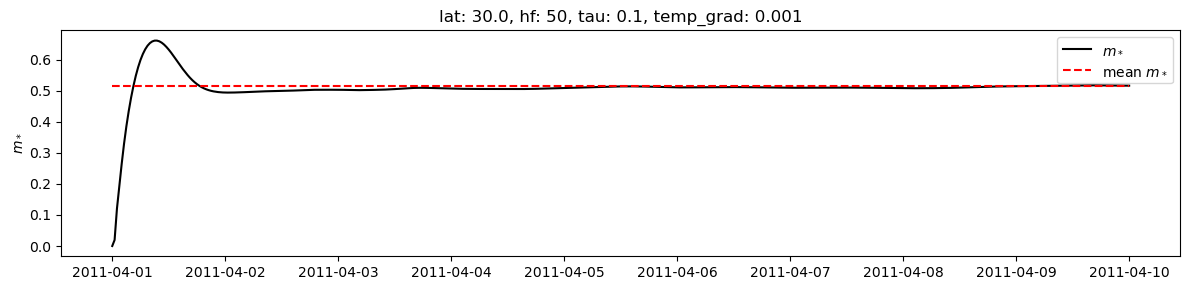

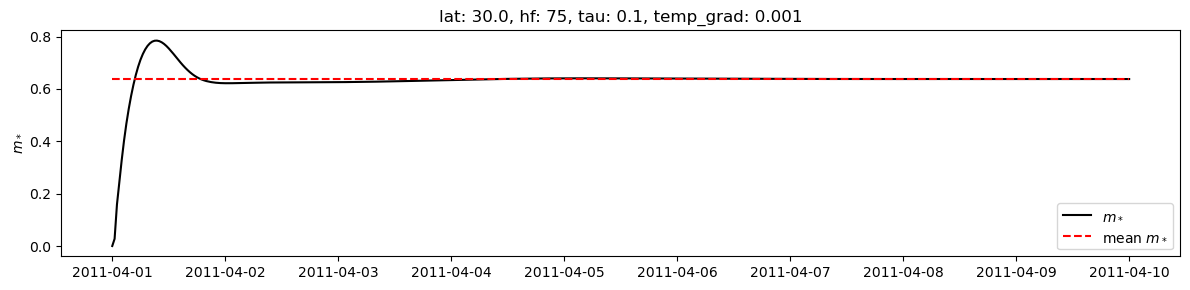

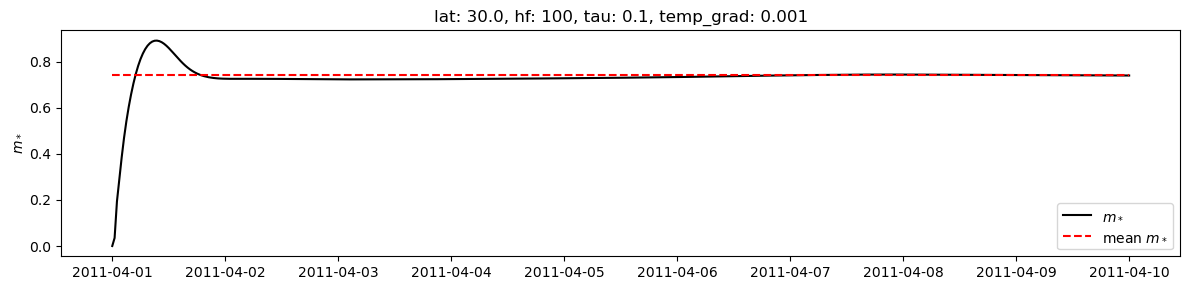

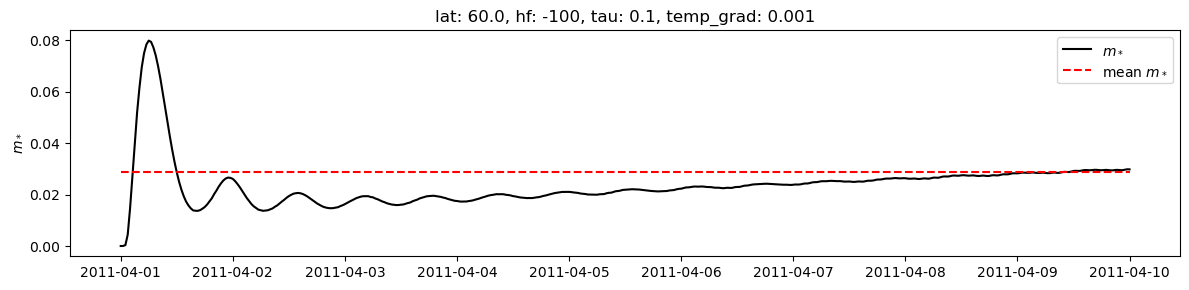

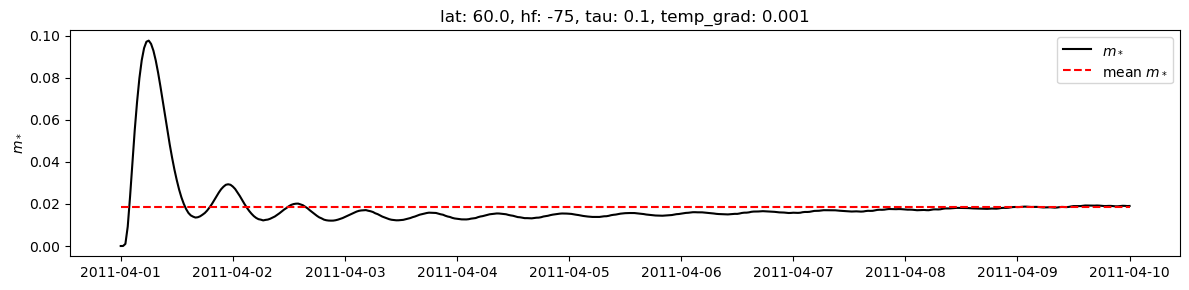

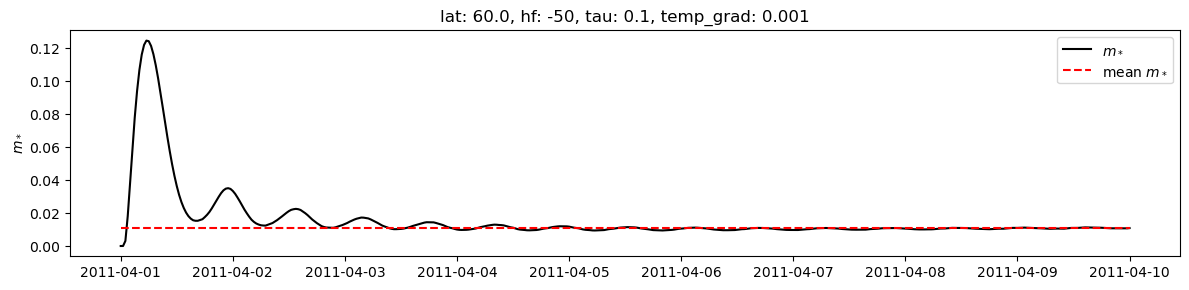

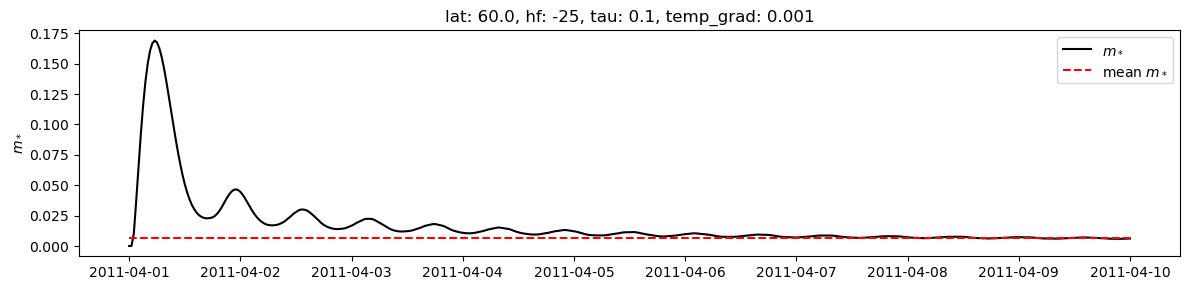

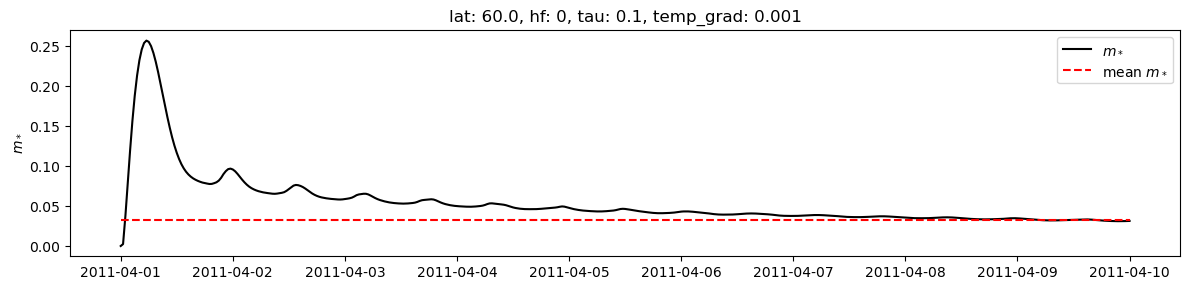

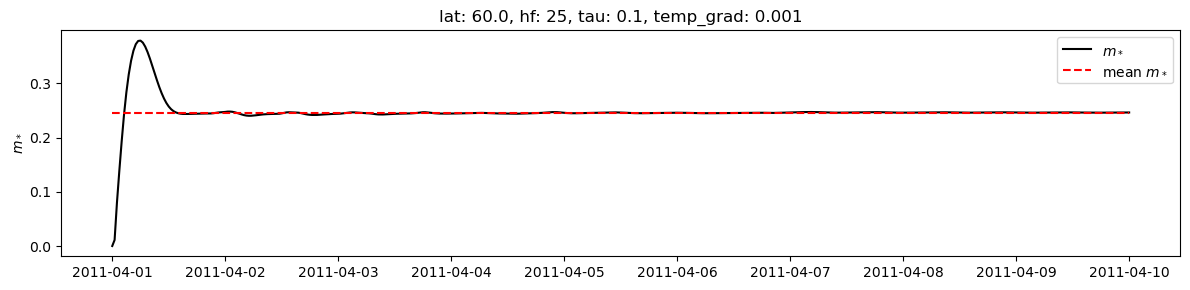

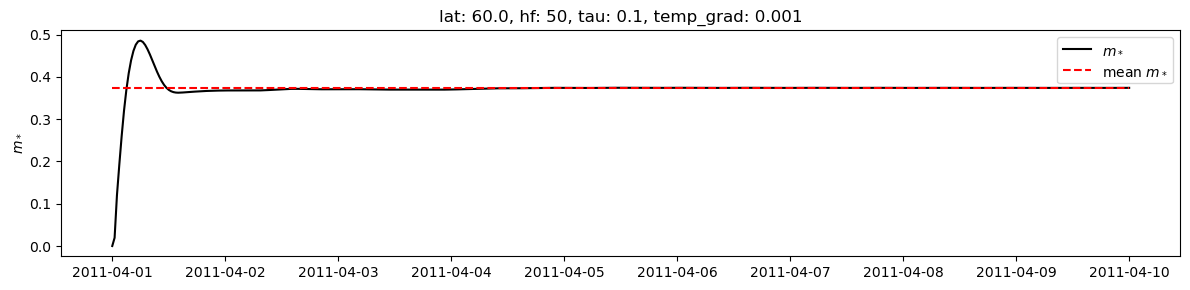

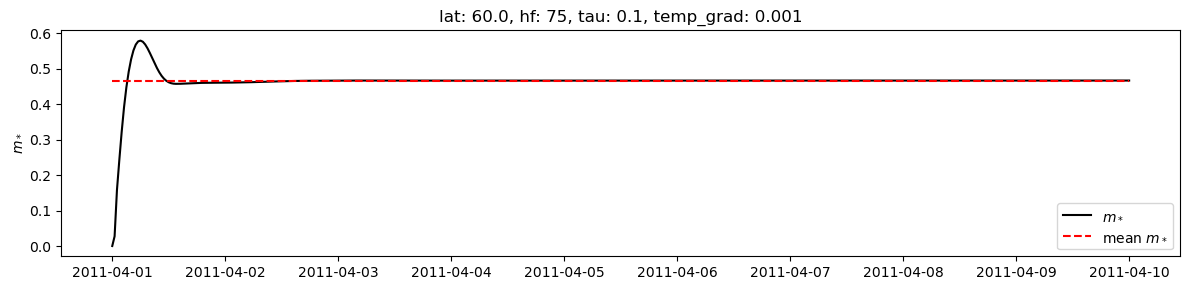

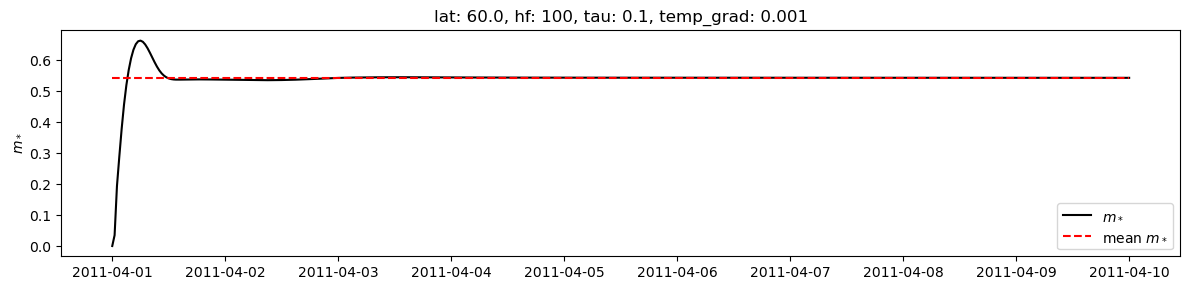

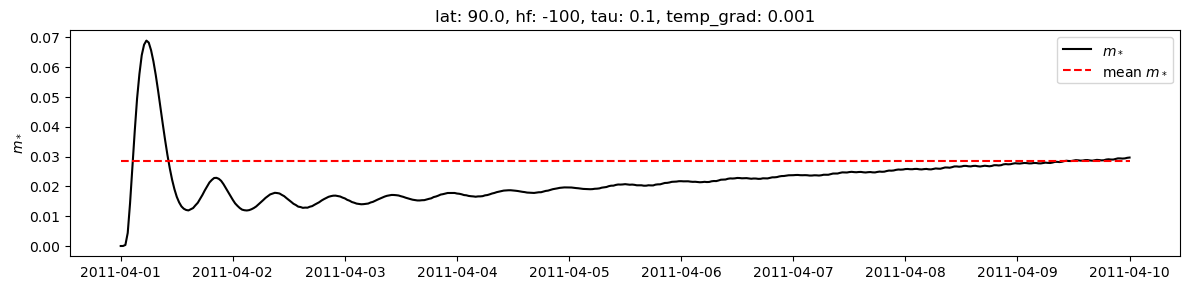

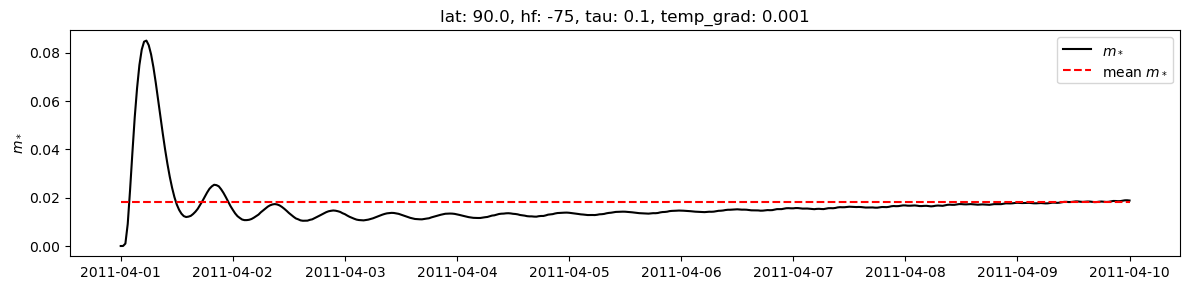

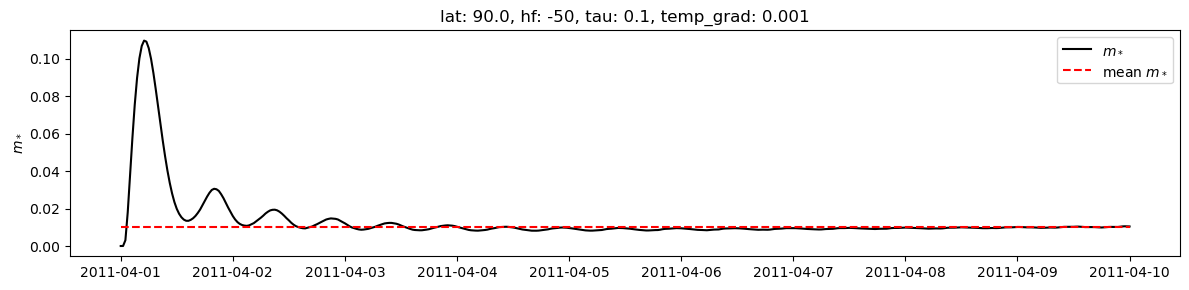

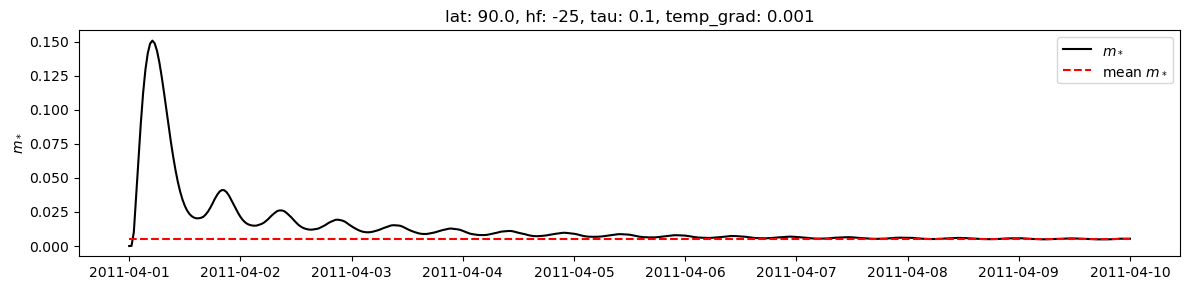

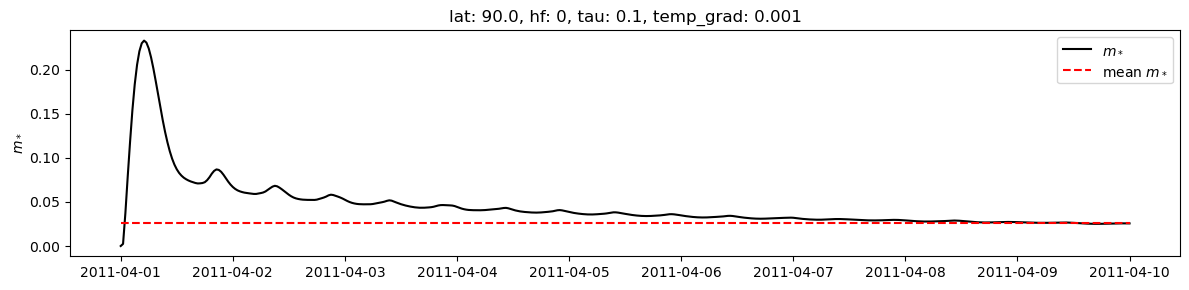

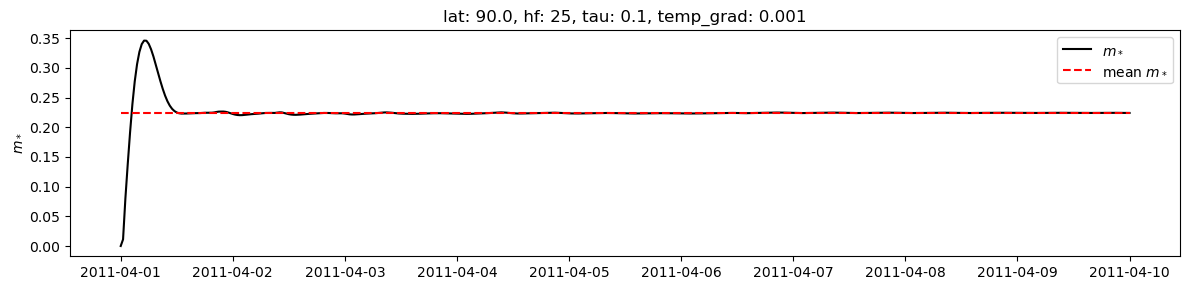

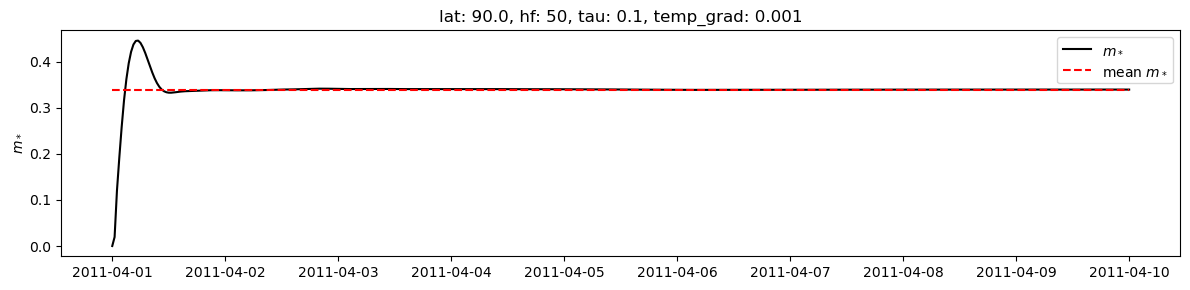

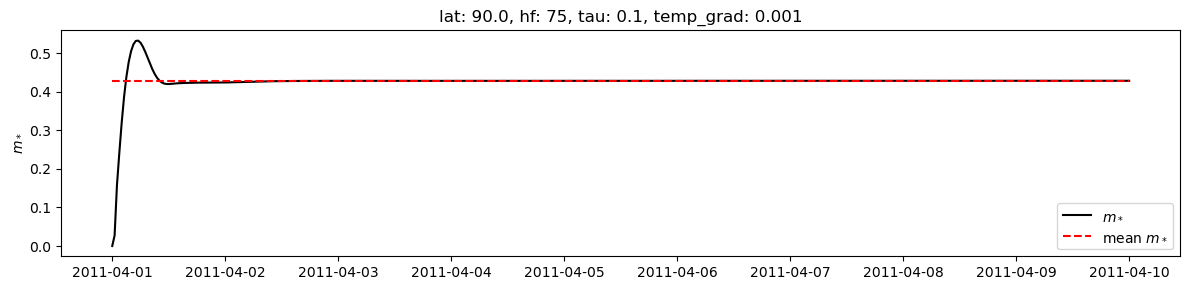

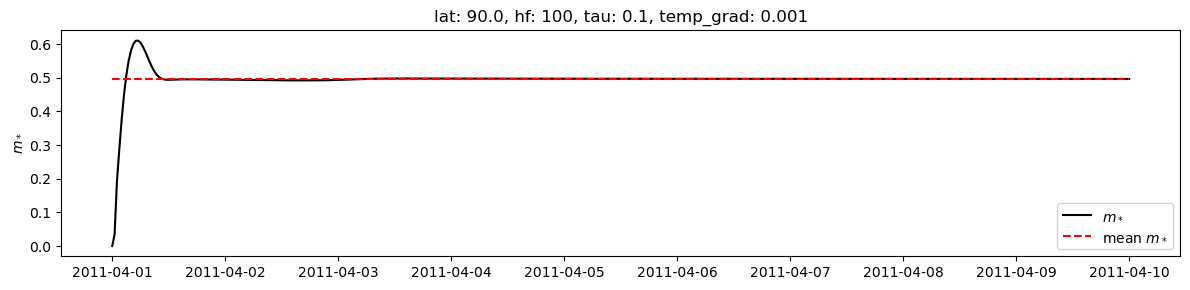

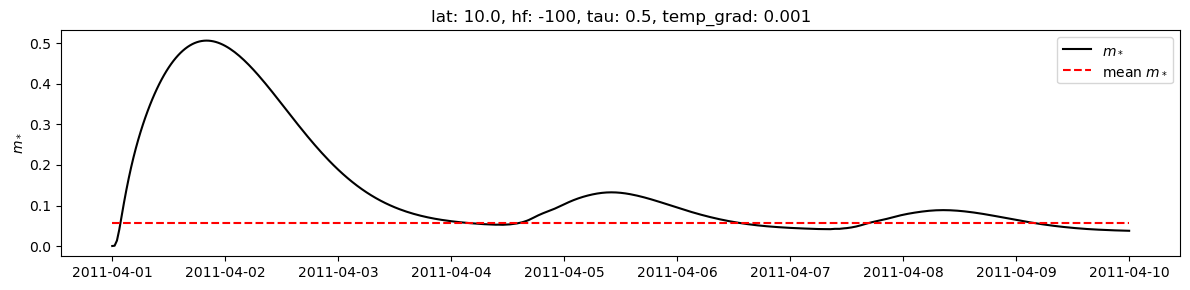

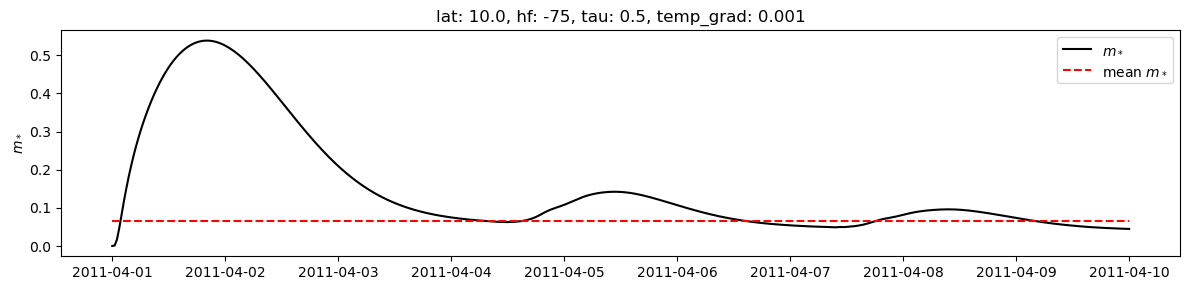

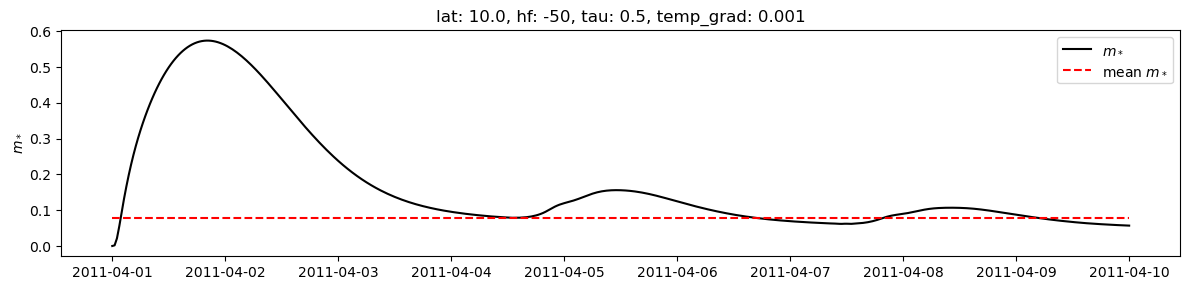

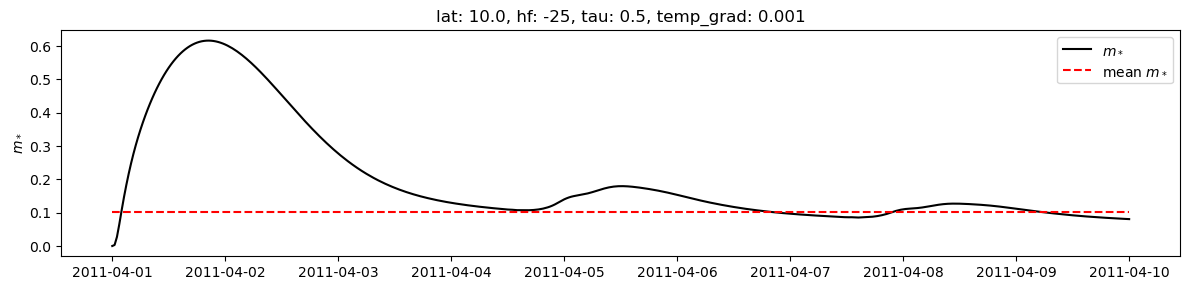

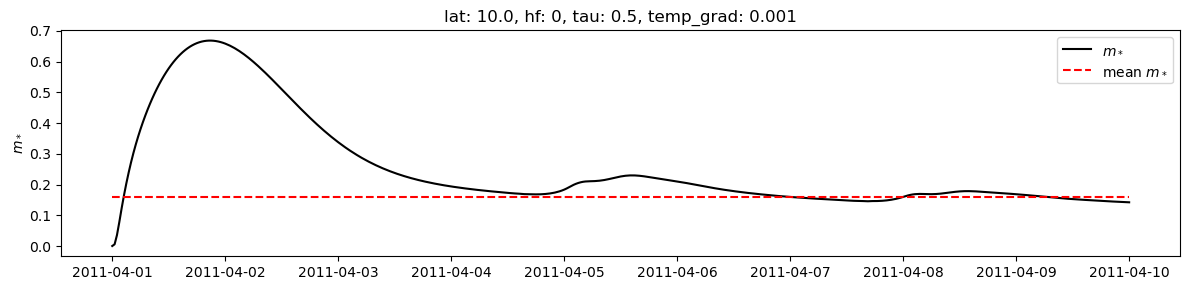

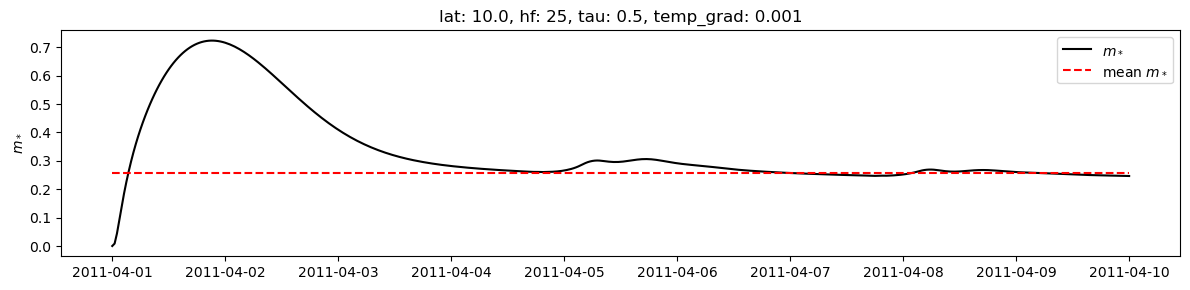

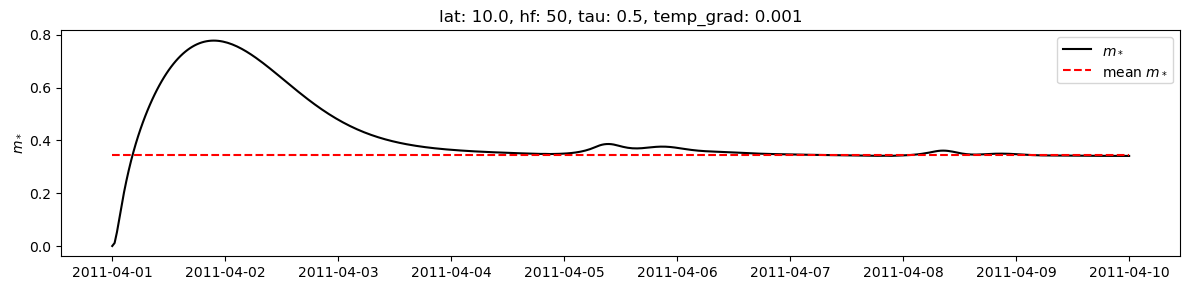

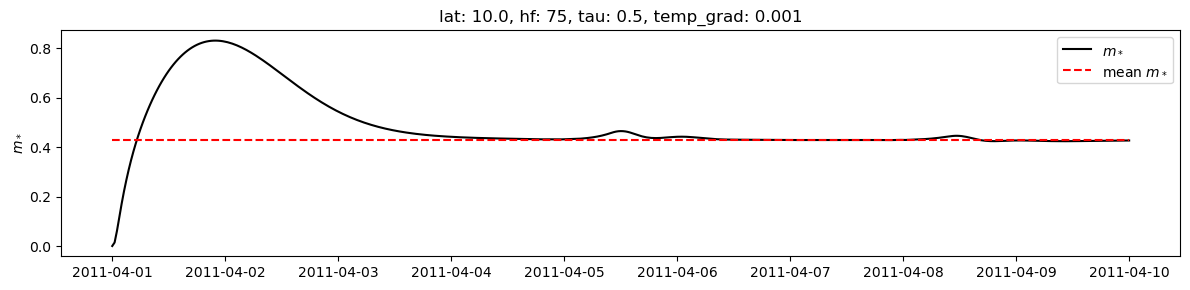

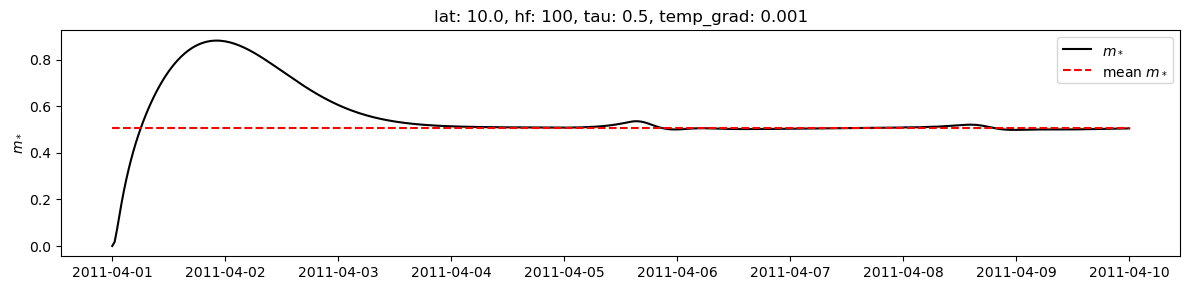

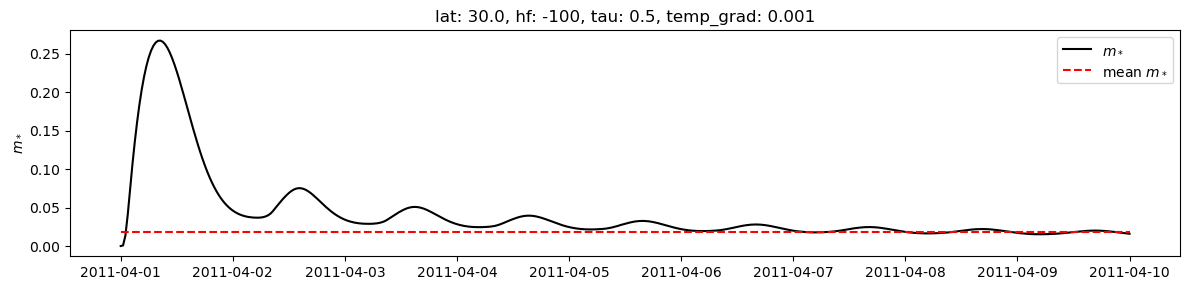

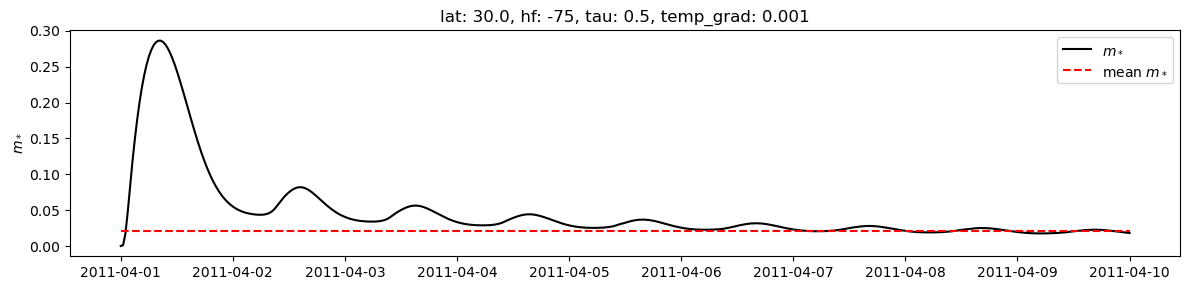

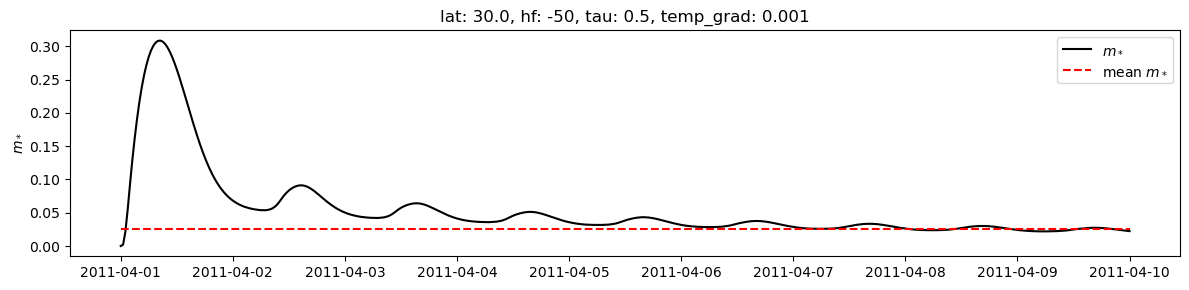

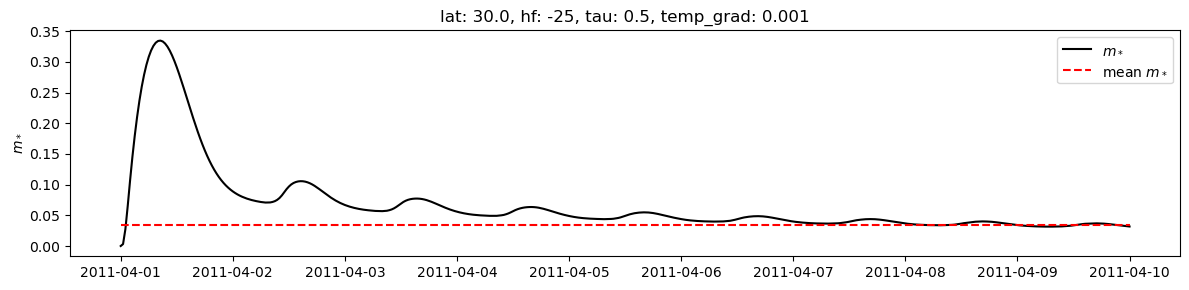

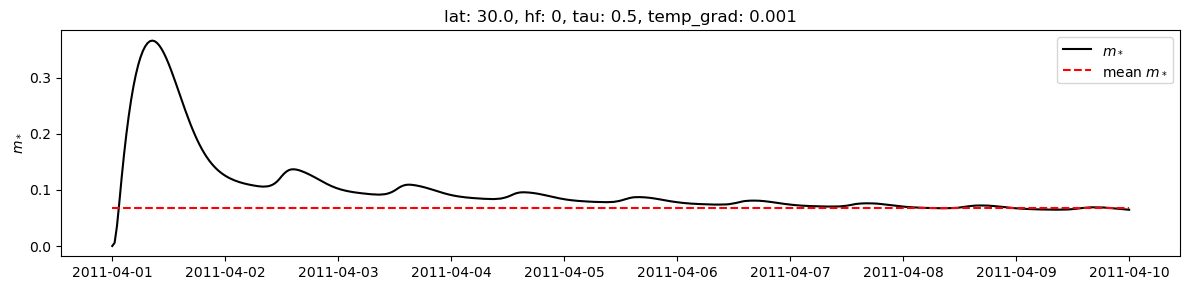

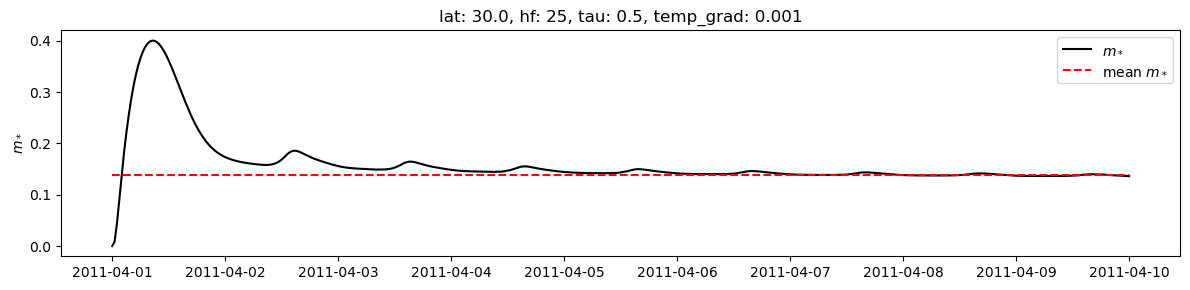

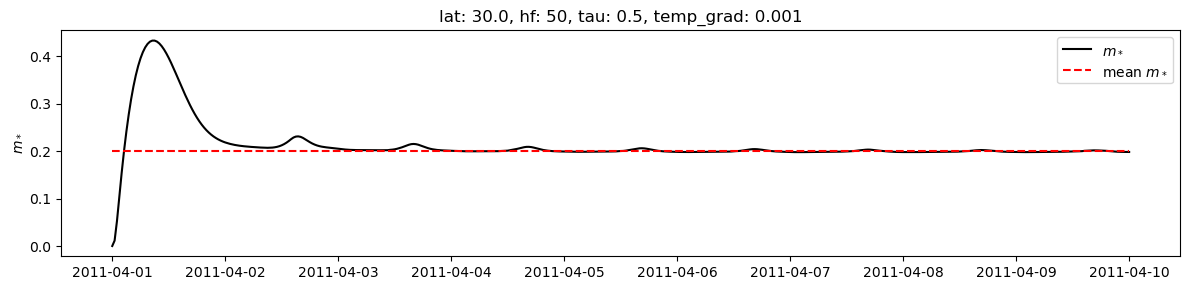

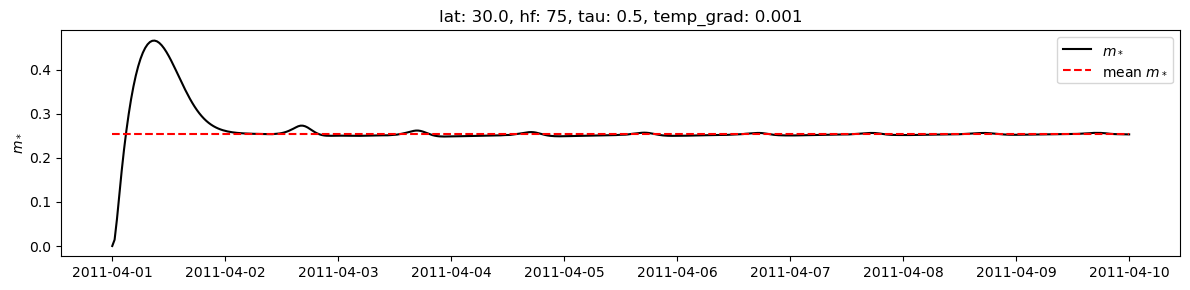

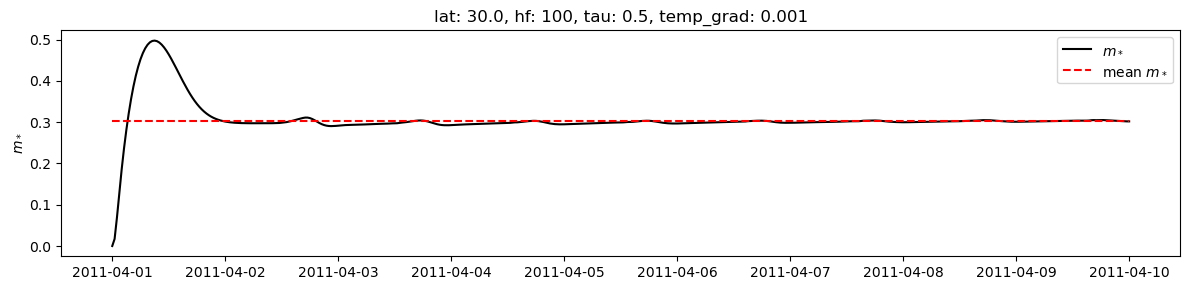

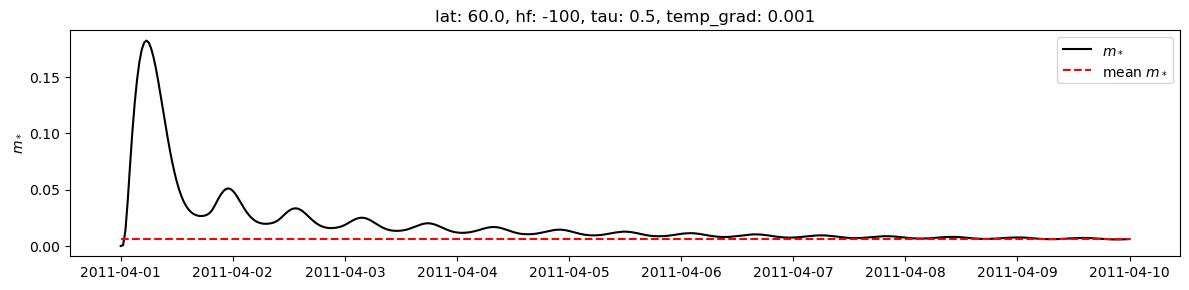

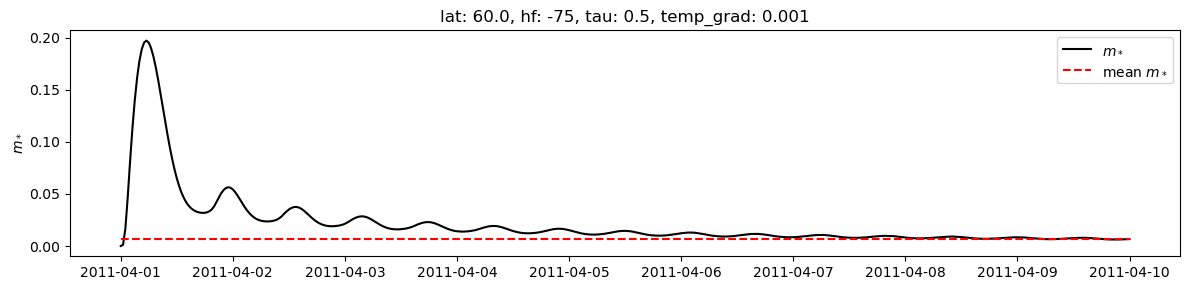

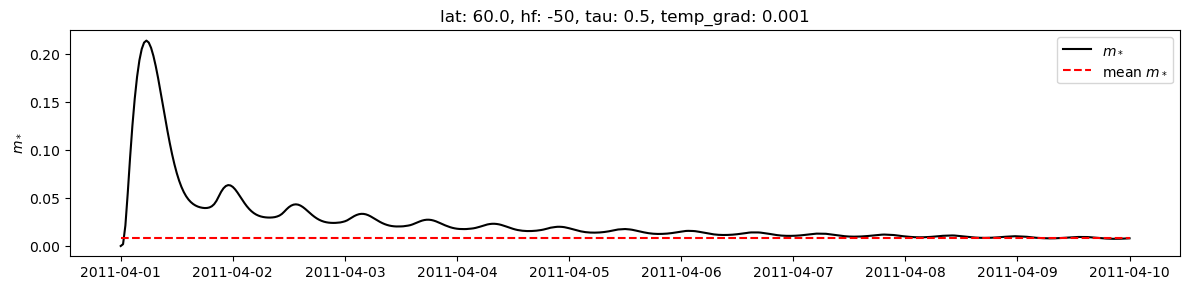

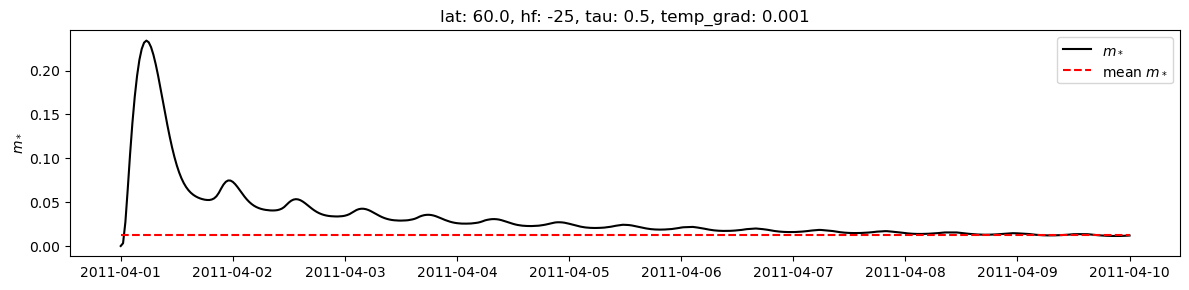

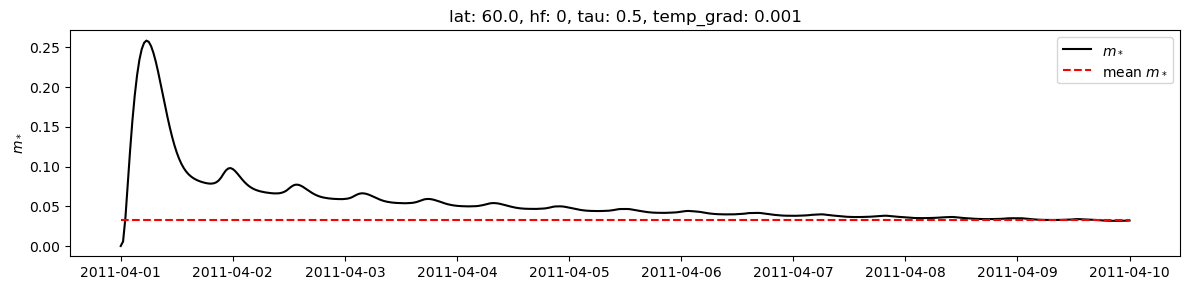

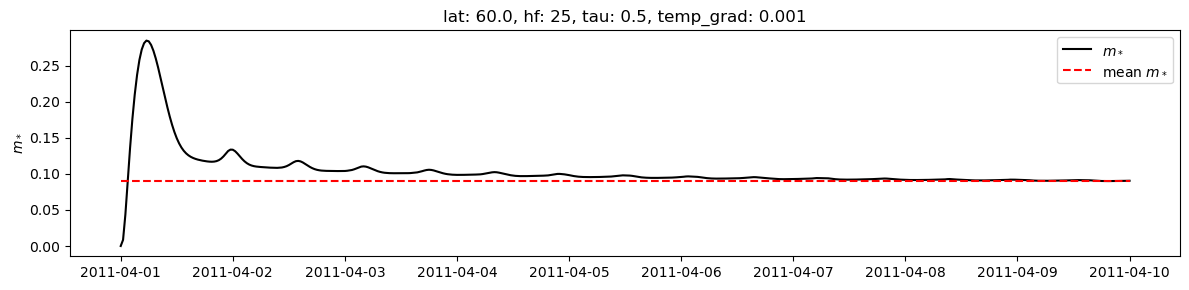

In [109]:
save = False

for i in range(1,60):
    plt.figure(figsize=(12,3))
    plt.plot(m_star_dataset.time.values, m_star_dataset.m_star.values[i,:], color="black",
             label="$m_*$")
    plt.plot(m_star_dataset.time.values, m_stars[i]*np.ones(len(m_star_dataset.m_star.values[i,:])), 
             color="red", linestyle="dashed", label="mean $m_*$")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/m_star_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}_hf_{hf}.png", dpi=300)

/tmp/ipykernel_526574/2315494667.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,3))


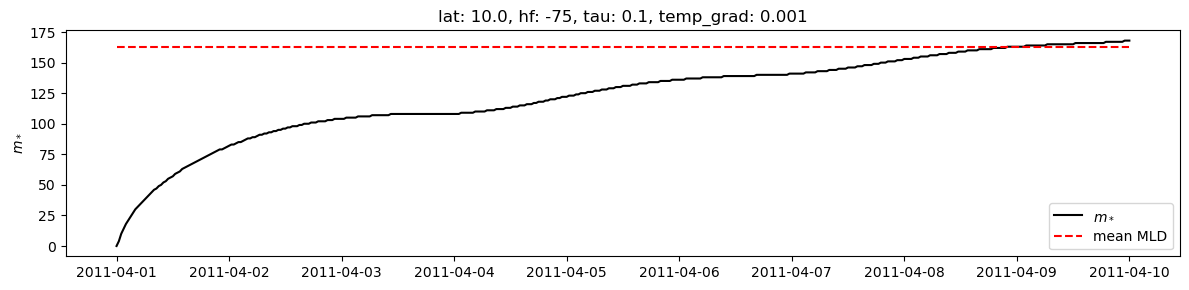

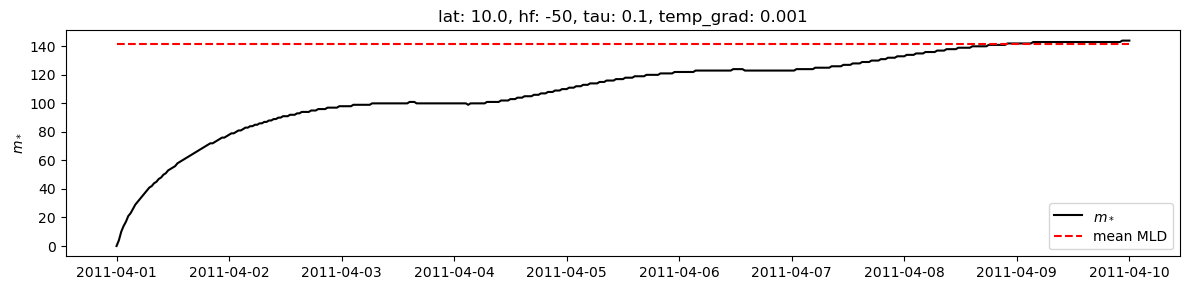

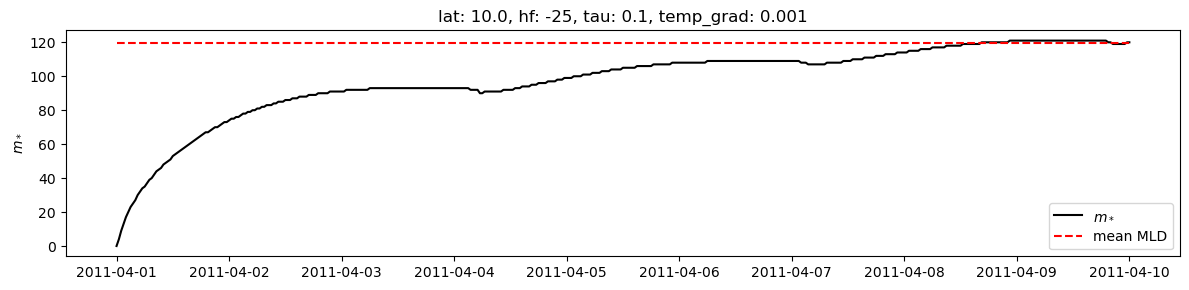

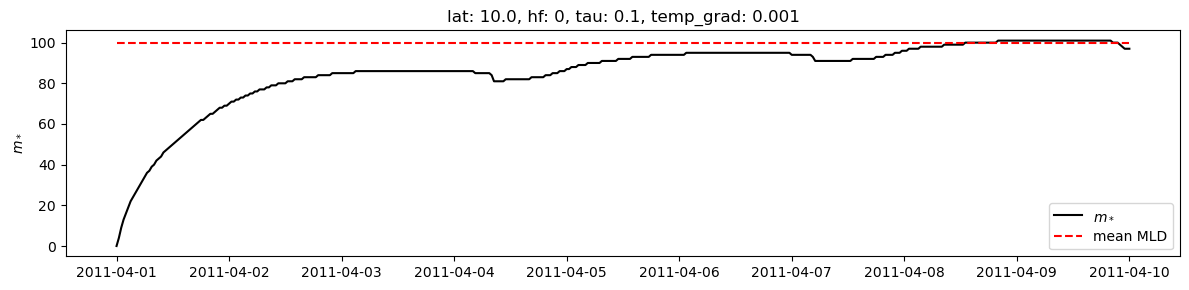

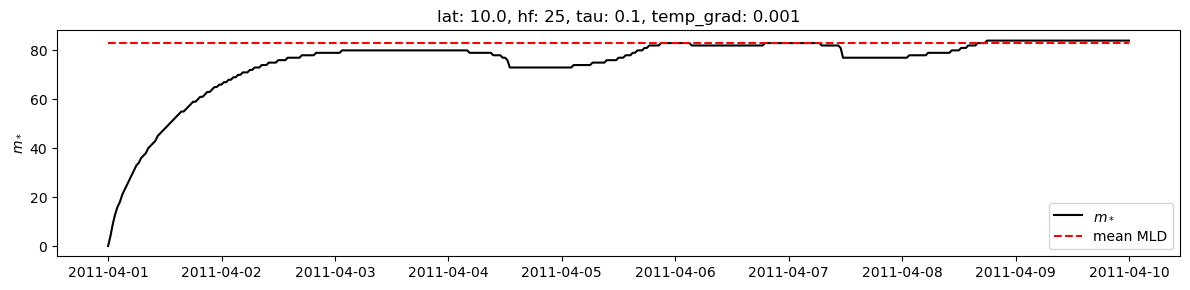

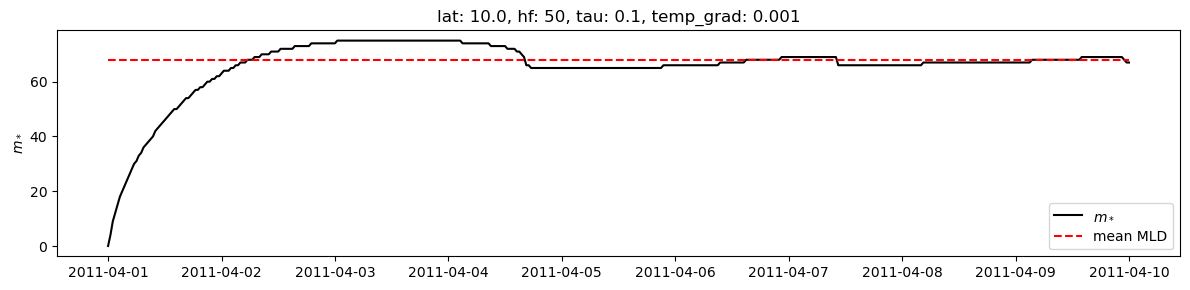

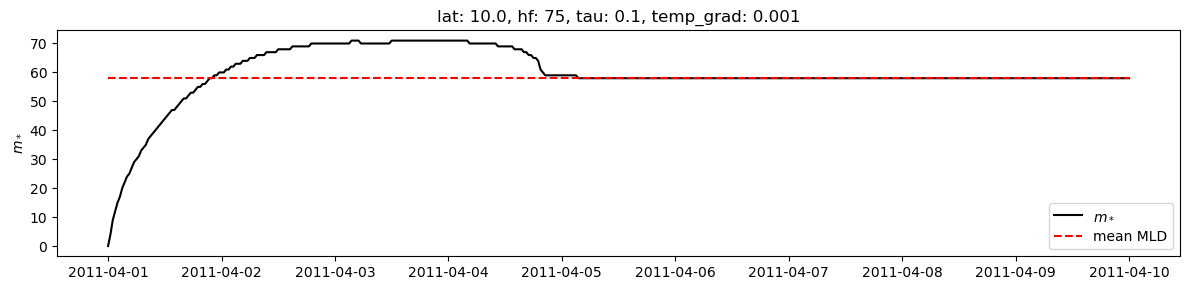

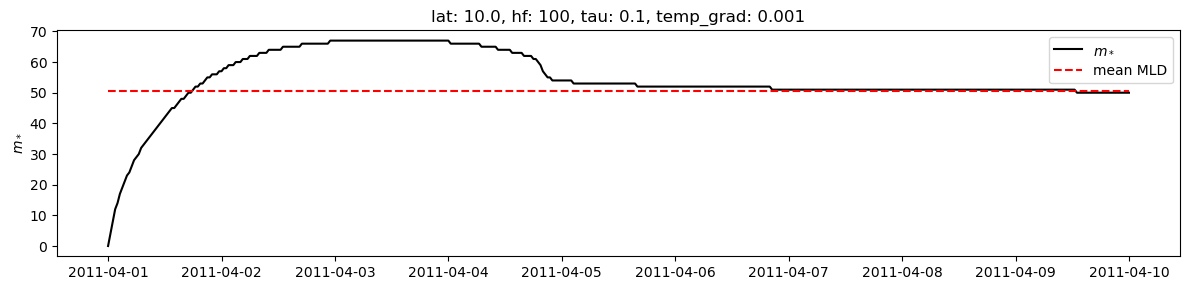

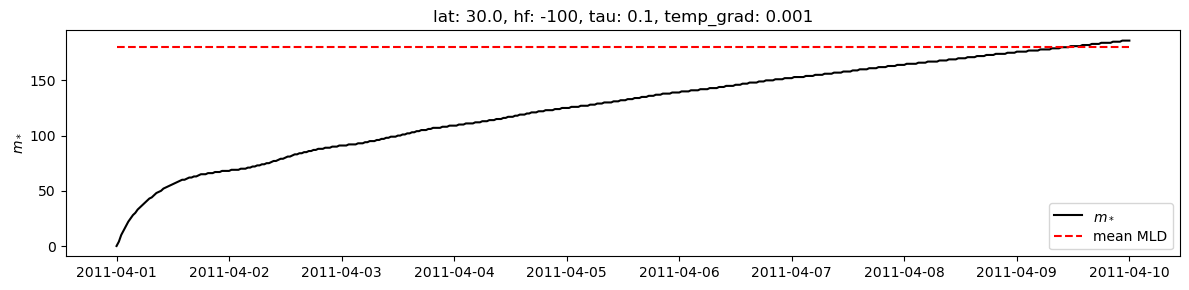

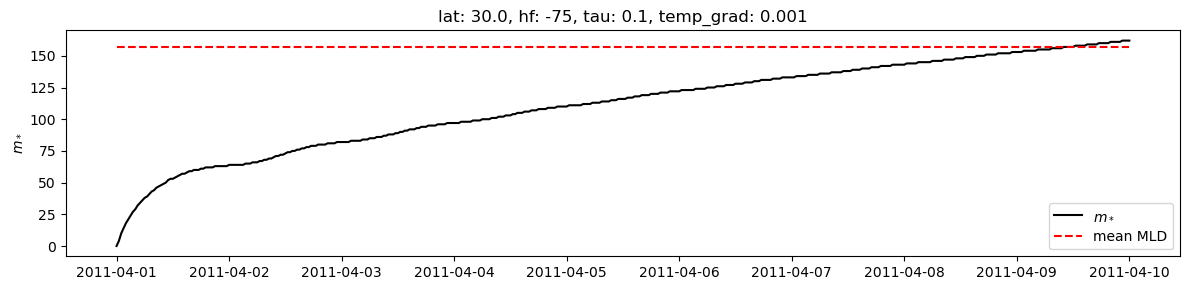

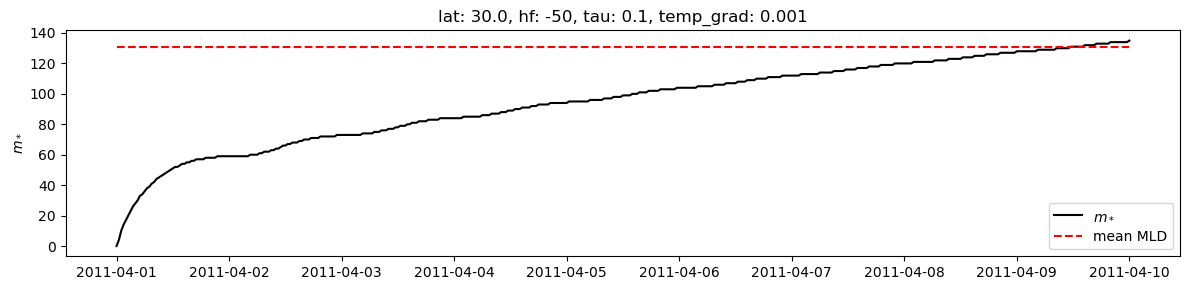

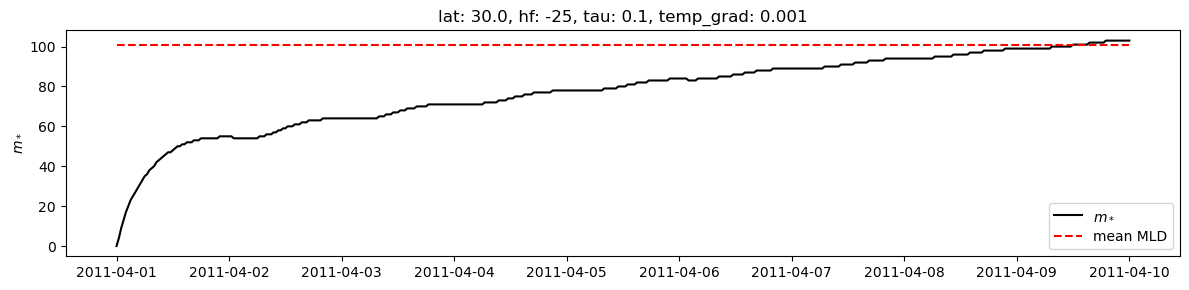

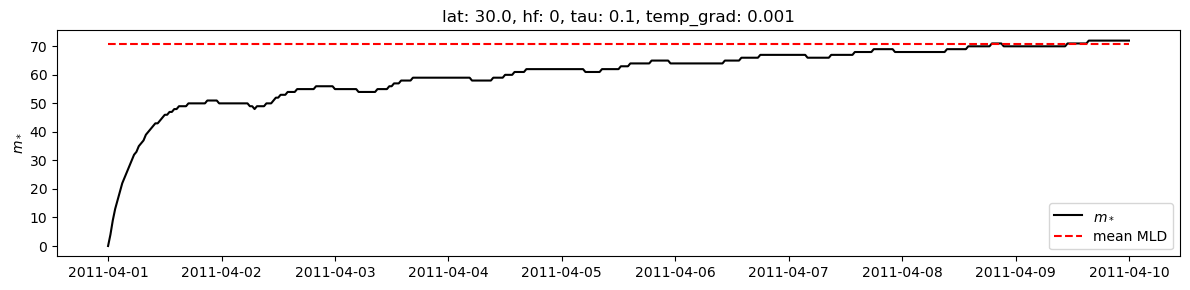

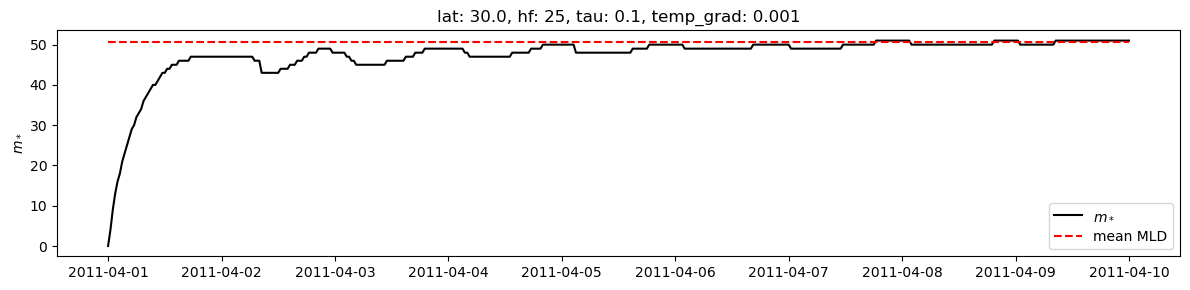

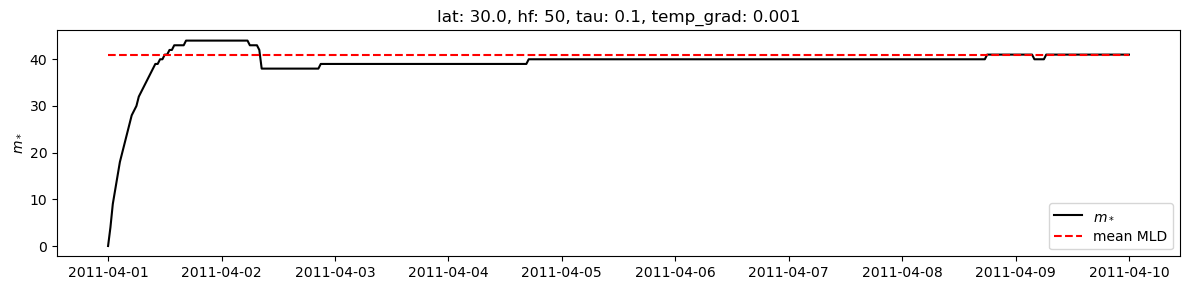

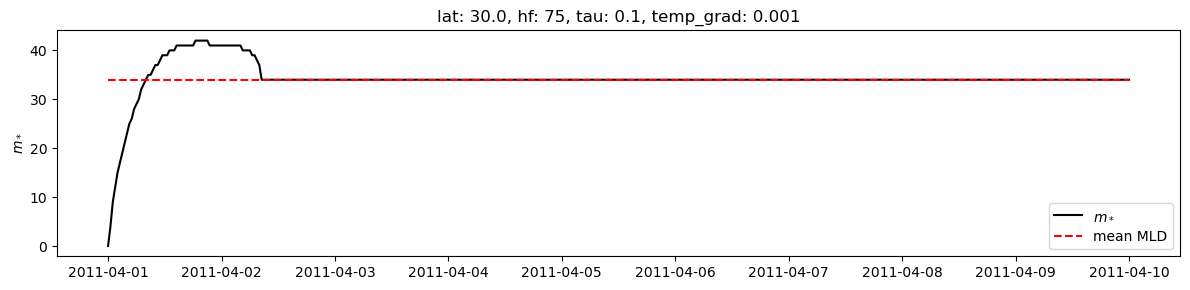

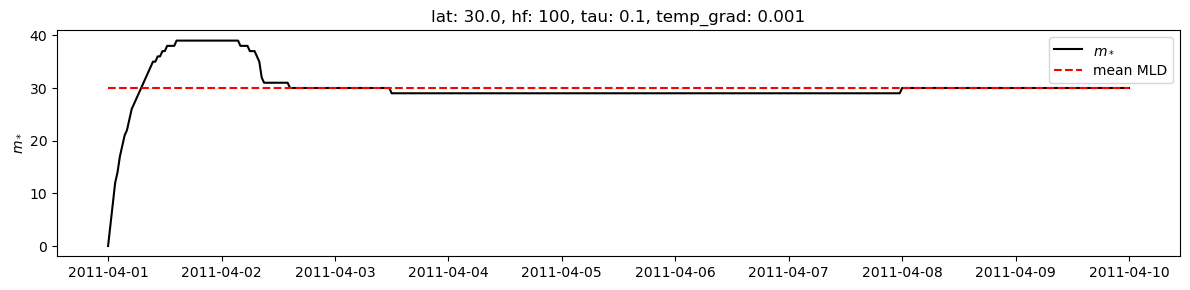

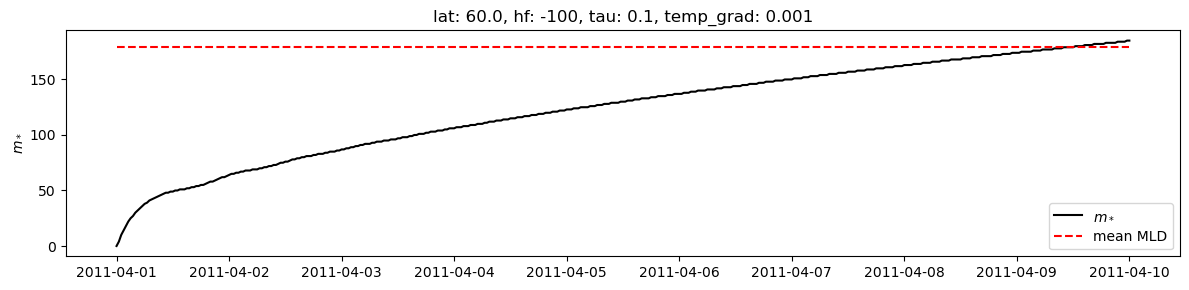

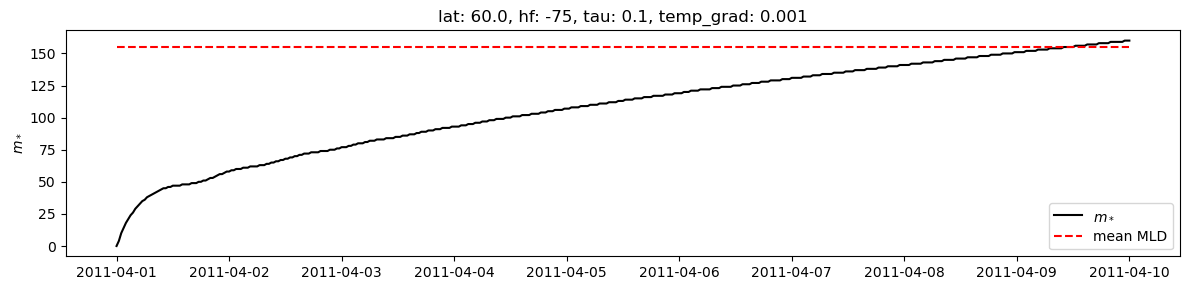

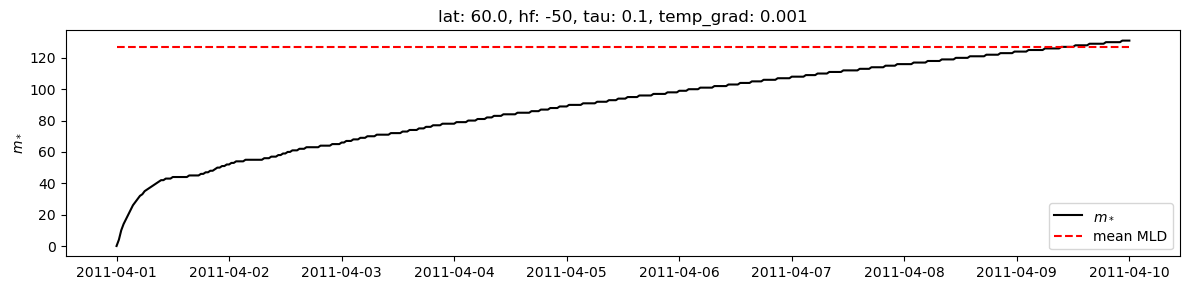

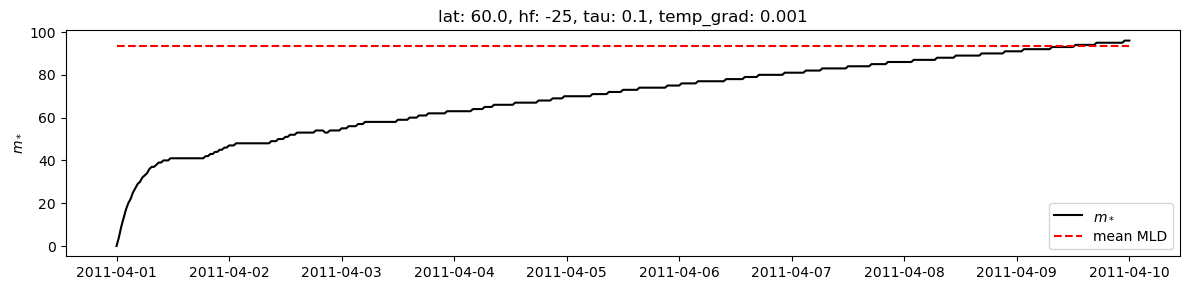

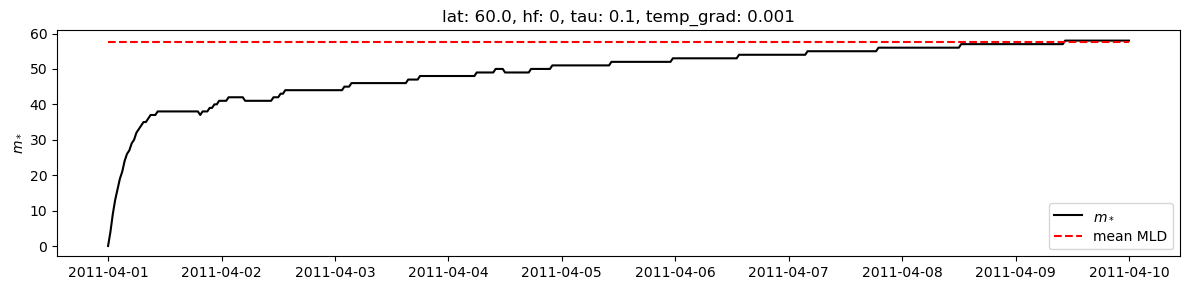

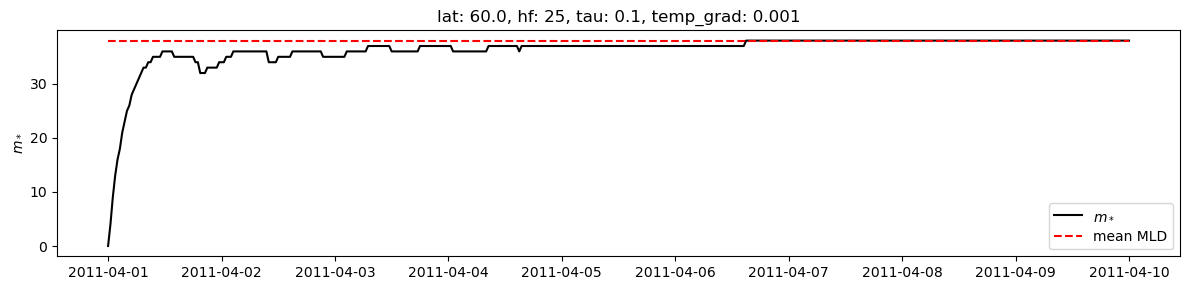

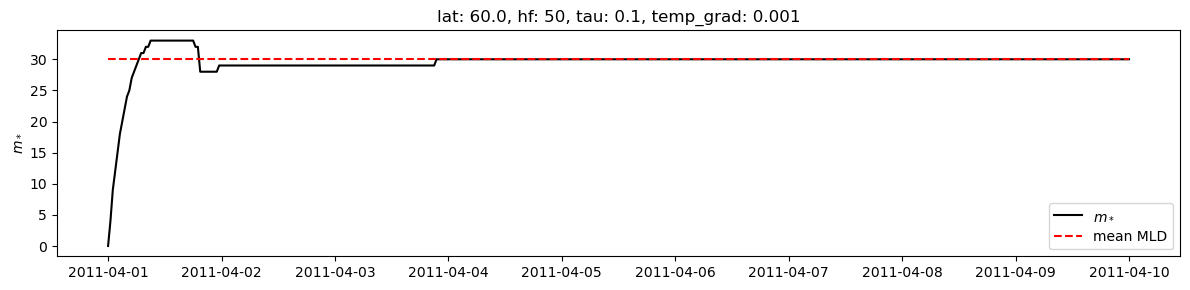

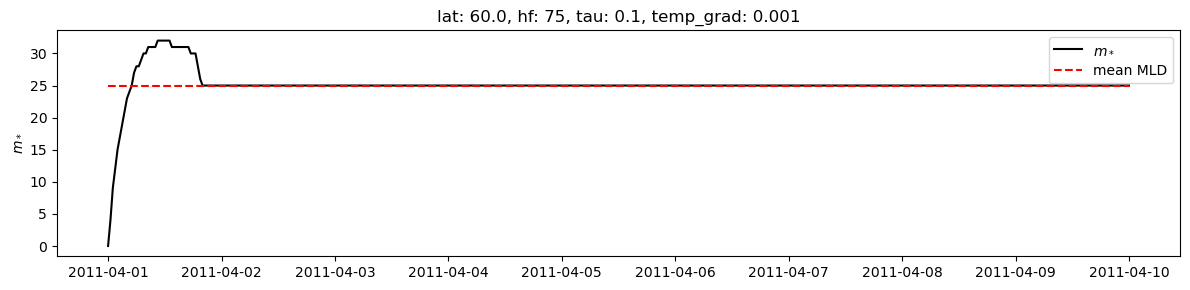

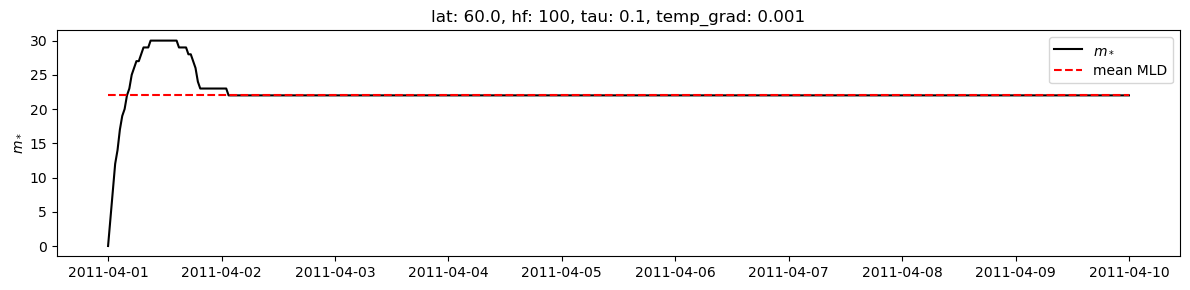

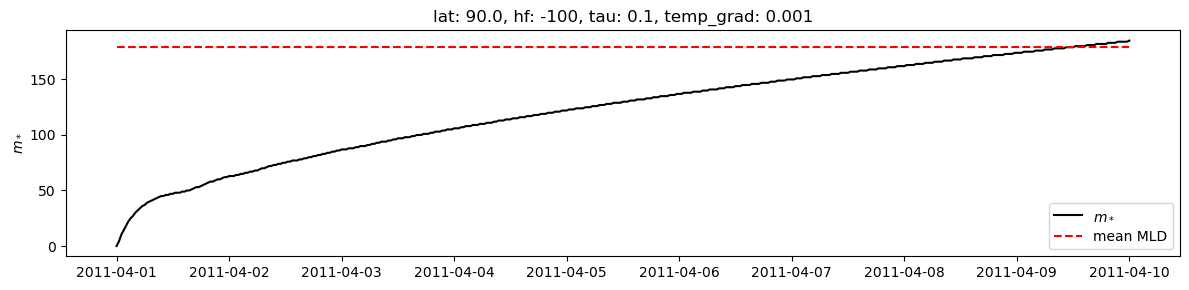

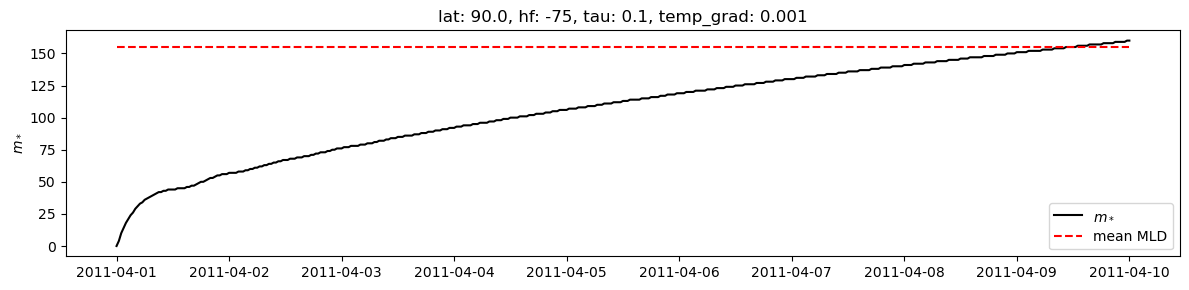

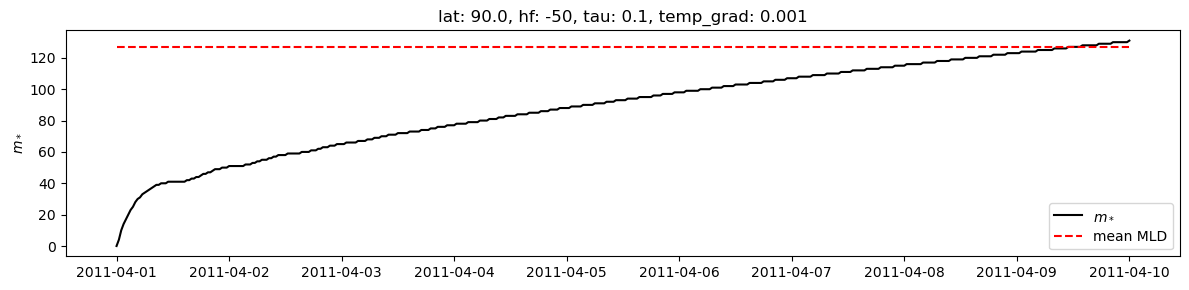

In [129]:
save = False

for i in range(1,30):
    plt.figure(figsize=(12,3))
    plt.plot(bl_dataset.time.values, bl_dataset.bl.values[i,:], color="black",
             label="$m_*$")
    plt.plot(bl_dataset.time.values, bls[i]*np.ones(len(bl_dataset.bl.values[i,:])), 
             color="red", linestyle="dashed", label="mean MLD")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/mld_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}.png", dpi=300)

In [31]:
xs = np.array([bls[i]*calculate_f(case['lat']) / (case['tx'] / 1027) ** 0.5 for i, case in enumerate(gotm_case_dict.values())])

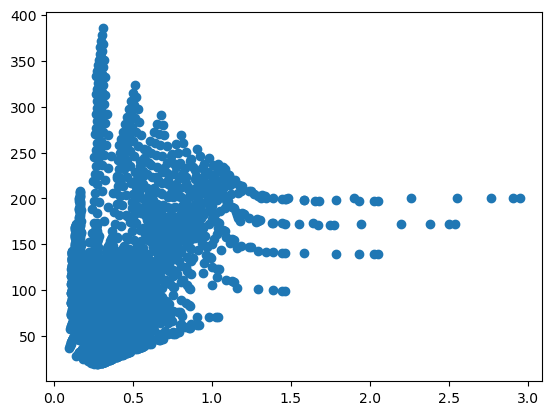

In [32]:
plt.scatter(xs, bls)

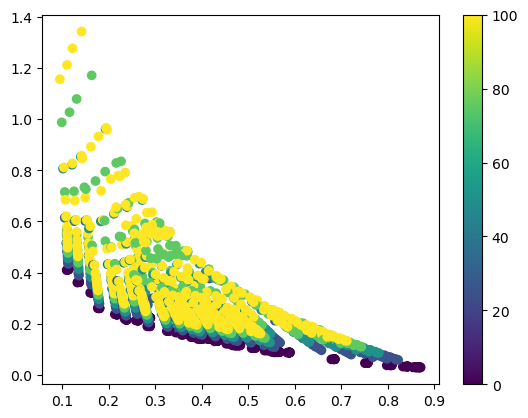

In [33]:
plt.scatter(xs[heat_fluxes >=0], m_stars[heat_fluxes >=0], c=heat_fluxes[heat_fluxes>=0])
plt.colorbar()

Text(0.5, 0, '$|f|H_{bl}/u_*$')

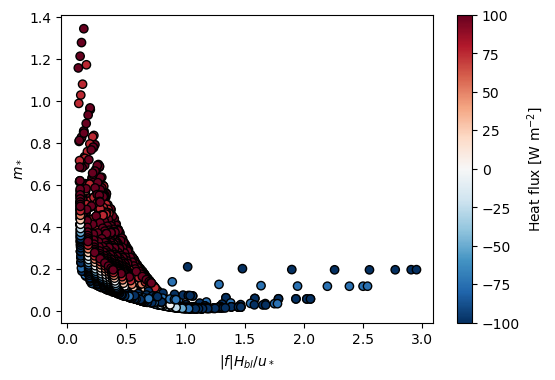

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(xs, m_stars, c=heat_fluxes, cmap="RdBu_r", edgecolors="black")
plt.colorbar(label="Heat flux [W m$^{-2}$]")
plt.ylabel("$m_*$")
plt.xlabel('$|f|H_{bl}/u_*$')

In [35]:
xs_no_hf = xs[heat_fluxes==0]
m_stars_no_hf = m_stars[heat_fluxes==0]
wind_stresses_no_hf = wind_stresses[heat_fluxes==0]

In [36]:
param_N, param_cov_N = curve_fit(calculate_analytical_m_star_N, xs_no_hf[xs_no_hf>0.3], m_stars_no_hf[xs_no_hf>0.3], maxfev=10000)

In [37]:
param_Nb, param_cov_Nb = curve_fit(calculate_analytical_m_star_Nb, xs_no_hf, m_stars_no_hf, maxfev=10000)

In [38]:
print(param_Nb, param_N)

[0.53984586 3.32628531] [0.3512185  4.05045898 4.36474812]


In [39]:
print(param_Nb, param_N)

[0.53984586 3.32628531] [0.3512185  4.05045898 4.36474812]


In [40]:
xs_N = np.linspace(0, 1, 1000)
m_star_N = calculate_analytical_m_star_N(xs_N, c_N1=0.275, c_N2 = 8.0, c_N3 = 5.0)
m_star_N_fitted = calculate_analytical_m_star_N(xs_N, c_N1=param_N[0], c_N2=param_N[1], c_N3=param_N[2])
m_star_Nb = calculate_analytical_m_star_Nb(xs_N, c_Nb1=0.5, c_Nb2=3.0)
m_star_Nb_fitted = calculate_analytical_m_star_Nb(xs_N, c_Nb1=param_Nb[0], c_Nb2=param_Nb[1])

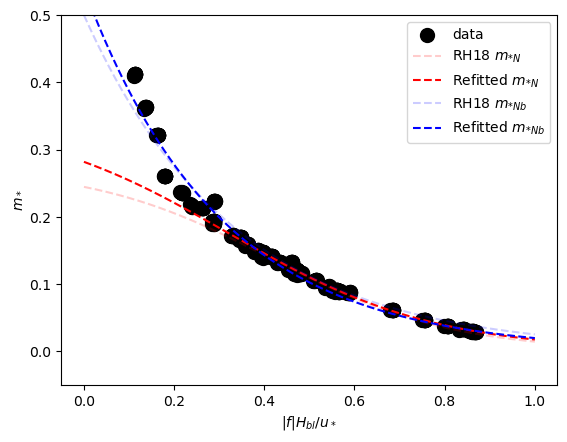

In [41]:
plt.scatter(xs_no_hf, m_stars_no_hf, color="black",
            label="data", s=100)
plt.plot(xs_N, m_star_N, color="red", linestyle="dashed", alpha=0.2, label="RH18 $m_{*N}$")
plt.plot(xs_N, m_star_N_fitted, color="red", linestyle="dashed", label="Refitted $m_{*N}$")
plt.plot(xs_N, m_star_Nb, color="blue", linestyle="dashed", alpha=0.2, label="RH18 $m_{*Nb}$")
plt.plot(xs_N, m_star_Nb_fitted, color="blue", linestyle="dashed", label="Refitted $m_{*Nb}$")

plt.ylabel('$m_*$')
plt.xlabel('$|f|H_{bl}/u_*$')
plt.ylim(-0.05, 0.5)

plt.legend()

# plt.savefig('analytical_m_star_corrected_G_and_BL_and_init_cond_2283.png', dpi=300)

In [88]:
criterion = np.logical_and(m_stars_no_hf<0.12, xs_no_hf<0.3)
m_stars_no_hf[criterion]

array([0.09989698])

In [91]:
cases_no_hf = cases[heat_fluxes == 0.]

In [92]:
cases_no_hf[criterion]

array([111])

In [93]:
gotm_case_dict["case_111"]

{'temp_grad': 0.001, 'tx': 1.0, 'lat': 10.0, 'heat_flux': 0}

In [28]:
xs_no_hf[xs_no_hf<0.18]

array([0.09684606, 0.07662154, 0.16397385, 0.07384873, 0.15360385,
       0.10362448, 0.08806268, 0.0847738 , 0.11664965, 0.10205737,
       0.10054444, 0.17481642, 0.17628083])

In [108]:
param_Nb

array([0.6014478 , 5.34636498])

In [109]:
param_N

array([3.07531700e+02, 9.50341811e-04, 2.48267958e+00])

In [51]:
m_stars[xs<0.15]

array([0.06860461, 0.07447092, 0.08590881, 0.11319754, 0.21270323,
       0.43341911, 0.63631921, 0.82285956, 0.98778909, 0.18945375,
       0.20480929, 0.22414484, 0.2488816 , 0.28200098, 0.31970406,
       0.3567113 , 0.39342481, 0.42954914, 0.24140859, 0.25278279,
       0.26597925, 0.28112565, 0.29838061, 0.31666654, 0.33516032,
       0.3530647 , 0.37124732, 0.06109941, 0.06533392, 0.07752787,
       0.10138289, 0.20095752, 0.44173056, 0.65641548, 0.84924468,
       1.01249501, 0.15280928, 0.16718627, 0.18549925, 0.21094185,
       0.24770003, 0.29112843, 0.33404653, 0.37574992, 0.41676496,
       0.19568515, 0.20744671, 0.22120212, 0.23755013, 0.257522  ,
       0.27892969, 0.30051888, 0.32149094, 0.34227587, 0.061648  ,
       0.07050712, 0.08928131, 0.18727698, 0.45141159, 0.67855344,
       0.8764068 , 1.03147922, 0.12363695, 0.13615493, 0.15337187,
       0.17859463, 0.21894319, 0.26938133, 0.31856684, 0.36599047,
       0.41257152, 0.15906052, 0.17089423, 0.18493982, 0.20229

In [50]:
calculate_analytical_m_star_Nb(xs[xs<0.15], c_Nb1=0.67004016, c_Nb2=11.22563986)

array([0.1978814 , 0.20823314, 0.21900761, 0.22935463, 0.22591949,
       0.1982848 , 0.18148905, 0.18908242, 0.198926  , 0.28168806,
       0.28159825, 0.28283389, 0.28367301, 0.28349993, 0.28285014,
       0.2828731 , 0.2829648 , 0.2821083 , 0.29309523, 0.29235464,
       0.29236231, 0.29334649, 0.29246308, 0.2929078 , 0.29341546,
       0.29363301, 0.29361269, 0.15541029, 0.16918113, 0.18385709,
       0.1991042 , 0.20936655, 0.17754232, 0.16112233, 0.17029808,
       0.18374662, 0.24001149, 0.24361203, 0.24614813, 0.24782425,
       0.24933009, 0.24957962, 0.25028222, 0.25014829, 0.25074973,
       0.25152933, 0.25344281, 0.25540036, 0.25666622, 0.25870736,
       0.25885299, 0.26097469, 0.26080386, 0.26094281, 0.12477358,
       0.14483808, 0.16417311, 0.18088667, 0.15452791, 0.14059775,
       0.15507558, 0.17945629, 0.1952318 , 0.20013113, 0.20443179,
       0.20891892, 0.21308228, 0.21613317, 0.21790343, 0.21950382,
       0.22019439, 0.20784629, 0.21057653, 0.21248409, 0.21459

In [54]:
np.sqrt(np.mean((calculate_analytical_m_star_N(xs_no_hf[xs_no_hf>0.15], c_N1=5.71097692e+02, c_N2=4.91134967e-04, c_N3=4.31117990e+00) - m_stars_no_hf[xs_no_hf>0.15]) ** 2))

np.float64(0.007059211505307918)

In [55]:
np.sqrt(np.mean((calculate_analytical_m_star_Nb(xs_no_hf[xs_no_hf<0.15], c_Nb1=0.67004016, c_Nb2=11.22563986) - m_stars_no_hf[xs_no_hf<0.15]) ** 2))

np.float64(0.006888117279246969)

Text(0, 0.5, 'm_star')

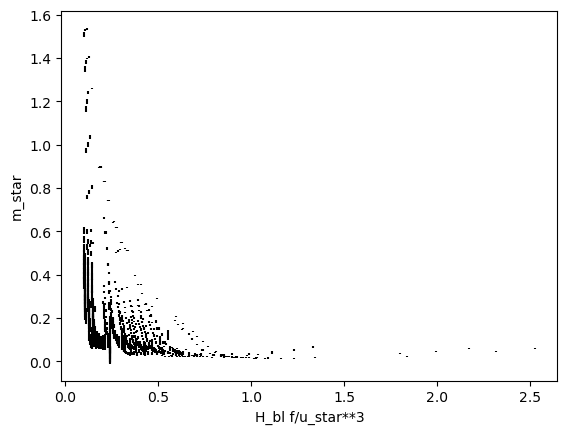

In [37]:
plt.figure()
plt.errorbar(xs, m_stars, yerr=np.sqrt(m_star_variances), color="black", linestyle="None")
plt.xlabel('H_bl f/u_star**3')
plt.ylabel('m_star')

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4014720/1138601053.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_{m_*}/m_*$')


(-0.5, 3.0)

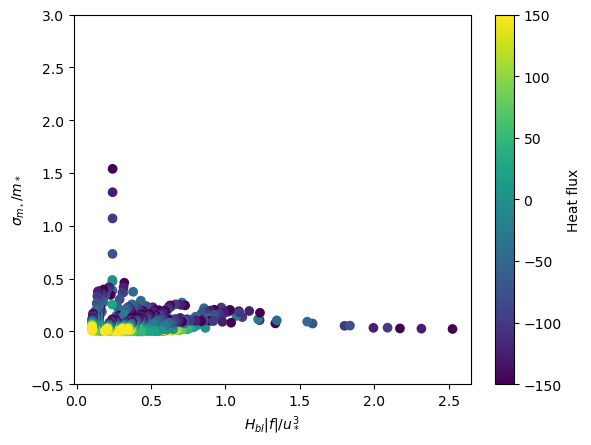

In [38]:
plt.scatter(xs, np.sqrt(m_star_variances)/m_stars, c=heat_fluxes)
plt.colorbar(label='Heat flux')
plt.ylabel('$\sigma_{m_*}/m_*$')
plt.xlabel('$H_{bl} |f|/u_*^3$')
plt.ylim(-0.5,3)
# plt.savefig('m_star_vs_m_star_variances.png', dpi=300)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3796103/1128819296.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_{m_*}/m_*$')
/tmp/ipykernel_3796103/1128819296.py:1: RuntimeWarning: invalid value encountered in divide
  plt.scatter(m_stars, np.sqrt(m_star_variances)/m_stars, c=heat_fluxes)


(-0.5, 3.0)

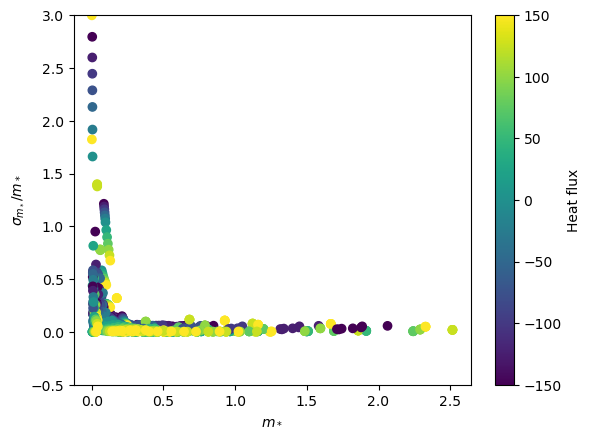

In [144]:
plt.scatter(m_stars, np.sqrt(m_star_variances)/m_stars, c=heat_fluxes)
plt.colorbar(label='Heat flux')
plt.ylabel('$\sigma_{m_*}/m_*$')
plt.xlabel('$m_*$')
plt.ylim(-0.5,3)
# plt.savefig('m_star_vs_m_star_variances.png', dpi=300)